In [2]:
from IPython.core.interactiveshell import InteractiveShell
import time

old_run_cell = InteractiveShell.run_cell

def timing_run_cell(self, raw_cell, *args, **kwargs):
    t0 = time.time()
    result = old_run_cell(self, raw_cell, *args, **kwargs)
    t1 = time.time()
    print(f"Execution time: {t1 - t0:.4f} seconds")
    return result

InteractiveShell.run_cell = timing_run_cell

In [3]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
# os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"
#os.environ["CUDA_VISIBLE_DEVICES"] = ""

import jax
print("backend:", jax.default_backend())
print("devices:", jax.devices())

backend: cpu
devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]
Execution time: 0.2926 seconds


# Import packages

In [4]:
import scipy.interpolate as spl
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
#import sys
from functools import partial
#import pickle
import itertools
import emcee
import corner
import jax.numpy as jnp
import jax.lax as lax
import jax.scipy as jsp
#import jax.extend
from multiprocessing import Pool
from jax import config
config.update("jax_enable_x64", True)
import pandas as pd
from decimal import Decimal, getcontext
import scipy.optimize as optimize
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation, PillowWriter
import scipy.integrate as spint
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from scipy.special import gammainc, gamma
from scipy.optimize import brentq
from fractions import Fraction
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor

Execution time: 1.2996 seconds


In [5]:
print(jax.devices())

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]
Execution time: 0.0003 seconds


In [6]:
BARY = pd.read_csv('../data/baryons.csv')
TOTAL = pd.read_csv('../data/galaxies_total_sample.csv')

BARY['Mass(Msun)'] =  pd.to_numeric(BARY['Mass(Msun)'], errors='coerce')
BARY['e_Mass(Msun)'] =  pd.to_numeric(BARY['e_Mass(Msun)'], errors='coerce')
BARY['j'] =  pd.to_numeric(BARY['j'], errors='coerce')
BARY['e_j'] =  pd.to_numeric(BARY['e_j'], errors='coerce')
BARY['fgas'] =  pd.to_numeric(BARY['fgas'], errors='coerce')
BARY['e_fgas'] =  pd.to_numeric(BARY['e_fgas'], errors='coerce')

TOTAL['Mstar'] =  pd.to_numeric(TOTAL['Mstar'], errors='coerce')
TOTAL['e_Mstar'] =  pd.to_numeric(TOTAL['e_Mstar'], errors='coerce')
TOTAL['Mgas'] =  pd.to_numeric(TOTAL['Mgas'], errors='coerce')
TOTAL['e_Mgas'] =  pd.to_numeric(TOTAL['e_Mgas'], errors='coerce')
TOTAL['jstar'] =  pd.to_numeric(TOTAL['jstar'], errors='coerce')
TOTAL['e_jstar'] =  pd.to_numeric(TOTAL['e_jstar'], errors='coerce')
TOTAL['jgas'] =  pd.to_numeric(TOTAL['jgas'], errors='coerce')
TOTAL['e_jgas'] =  pd.to_numeric(TOTAL['e_jgas'], errors='coerce')

obs_Mbar = np.log10(BARY['Mass(Msun)'].values.copy())
obs_Mbar_errors = BARY['e_Mass(Msun)'].values.copy()/BARY['Mass(Msun)'].values.copy()
obs_Mgas = np.log10(TOTAL['Mgas'].values.copy())
obs_Mgas_errors = TOTAL['e_Mgas'].values.copy()/TOTAL['Mgas'].values.copy()
obs_Mstar = np.log10(TOTAL['Mstar'].values.copy())
obs_Mstar_errors = TOTAL['e_Mstar'].values.copy()/TOTAL['Mstar'].values.copy()
obs_jbar = np.log10(BARY['j'].values.copy())
obs_jbar_errors = BARY['e_j'].values.copy()/BARY['j'].values.copy()
obs_jgas = np.log10(TOTAL['jgas'].values.copy())
obs_jgas_errors = TOTAL['e_jgas'].values.copy()/TOTAL['jgas'].values.copy()
obs_jstar = np.log10(TOTAL['jstar'].values.copy())
obs_jstar_errors = TOTAL['e_jstar'].values.copy()/TOTAL['jstar'].values.copy()
obs_fgas = BARY['fgas'].values.copy()
obs_fgas_errors = BARY['e_fgas'].values.copy()
obs_fgas_but_for_stars_and_gas = TOTAL['Mgas'].values.copy()/(TOTAL['Mgas'].values.copy() + TOTAL['Mstar'].values.copy())
obs_fgas_but_for_stars_and_gas_errors = np.sqrt( (TOTAL['e_Mgas'].values.copy()/(TOTAL['Mgas'].values.copy() + TOTAL['Mstar'].values.copy()))**2 + (TOTAL['Mgas'].values.copy()*TOTAL['e_Mstar'].values.copy()/((TOTAL['Mgas'].values.copy() + TOTAL['Mstar'].values.copy())**2))**2 )
pavel_dir = '../data/compilation_AM_others/'

pavel_data = {}

for filename in os.listdir(pavel_dir):
    if filename.endswith('.csv'):
        filepath = os.path.join(pavel_dir, filename)
        
        df = pd.read_csv(filepath)
        
        df_name = os.path.splitext(filename)[0]
        #add to superthin: 9.04,2.95,9.85,0.55,9.912537485,2.088484546,0.8658895825
        pavel_data[df_name] = df

HIX_logMstar = np.array([10.5, 10.7, 10.5, 10.5, 10.3, 10.2,  9.8, 10.1, 10.1, 10.1, 10.6, 10.5])
HIX_logMHI = np.log10(1.4 * 10**np.array([10.6, 10.7, 10.5, 10.5, 10.4, 10.3,  9.9, 10.3, 10.4, 10.3, 10.9, 10.5]))
HIX_logMbar = np.log10(10**HIX_logMstar + 10**HIX_logMHI)
HIX_fgas = (10**HIX_logMHI)/(10**HIX_logMbar)
HIX_jbar = np.array([4125.6, 3523.8, 5453.1, 4092.4, 3522.7, 3749.8, 1993. , 3196.7, 3388.2, 6377.8, 9764. , 4117.7])

Execution time: 0.0092 seconds


In [7]:
M_times1 = np.arange(0,12.2,0.1)
M_times1_jax = jnp.array(M_times1, dtype=jnp.float64)
log_M_bar_array = np.linspace(8,11.5,50)
dt = 0.1
N = 1.4
A = 0.1625
Rf = 0.3

t_end = float(M_times1[-1])
n_t = M_times1_jax.shape[0]
log_M_bar_array_jax = jnp.array(log_M_bar_array, dtype=jnp.float64)

Execution time: 0.0221 seconds


In [8]:
def RungeKutta(x, y, dx, dydx):
    # Calculate slopes
    k1 = dx * dydx(x, y)
    k2 = dx * dydx(x + dx / 2., y + k1 / 2.)
    k3 = dx * dydx(x + dx / 2., y + k2 / 2.)
    k4 = dx * dydx(x + dx, y + k3)
    
    # Calculate new x and y
    y_new = y + (1. / 6.) * (k1 + 2 * k2 + 2 * k3 + k4)
    x_new = x + dx
    
    return x_new, y_new

def Sigma_definer(r, r_acc, t_acc, C):
    """
    Defines the gas surface density 2D array M_sigma(r, t).

    r      : 1D radius array (pc)
    r_acc  : scalar accretion scale length (pc)
    t_acc  : scalar accretion timescale (Gyr)
    C      : normalization constant to reach desired M_bar at t0
    """
    n_r = len(r)
    n_t = len(M_times1)
    M_sigma = np.zeros((n_r, n_t))

    # assume M_times1 is monotonically increasing with constant spacing dt
    dt_local = M_times1[1] - M_times1[0]
    t_end = M_times1[-1]

    for i, r_value in enumerate(r):
        def dydx(t, S):
            # accretion term - KS consumption term
            acc = (C / (2.0 * np.pi * (r_acc**2))) * np.exp(-t / t_acc) * np.exp(-r_value / r_acc)
            sfr = SFL(S)
            return acc - sfr

        # initial conditions
        t = 0.0
        S = 0.0
        S_row = np.zeros(n_t)
        S_row[0] = S

        # integrate forward in time following M_times1 grid
        for j in range(1, n_t):
            t, S = RungeKutta(t, S, dt_local, dydx)
            S_row[j] = S

        M_sigma[i, :] = S_row

    return M_sigma


def SFL(sigma, sfl_type='old_ksl'):
    Rf = 0.3
    sigma_arr = np.asarray(sigma, dtype=float)

    # Enforce physical domain: negative gas is set 0
    sigma_pos = np.where(sigma_arr > 0.0, sigma_arr, 0.0)

    if sfl_type == "old_ksl":
        N = 1.4
        A = 0.1625
        SFL_val = (1 - Rf) * A * (sigma_pos**N)
    
    elif sfl_type == "elise_steep":
        N = 2.47
        A = 2.13e-5
        SFL_val = (1 - Rf) * A * (sigma_pos**N)

    elif sfl_type == "new_ksl":
        A_ksl = 5.18e-4
        N_ksl = 3.83
        SFL_val = (1 - Rf) * A_ksl * (sigma_pos**N_ksl)

    elif sfl_type == "cutoff_ksl":
        thr = 1.0239163123543726

        with np.errstate(divide='ignore', invalid='ignore'):
            log_sigma = np.where(sigma_pos > 0.0, np.log10(sigma_pos), -np.inf)

        mask = log_sigma < thr

        low_reg  = (1 - Rf) * 5.20e-4 * (sigma_pos**3.83)
        high_reg = (1 - Rf) * 0.1625   * (sigma_pos**1.4)

        SFL_val = np.where(mask, low_reg, high_reg)

    else:
        raise ValueError(f"Unknown sfl_type: {sfl_type}")

    SFL_val = np.where(np.isfinite(SFL_val), SFL_val, 0.0)

    if np.isscalar(sigma):
        return float(SFL_val)
    return SFL_val

def SFL_jax(sigma, sfl_type, R, Mbar):
    Rf = 0.3
    if sfl_type == "old_ksl":
        N = 1.4
        A = 0.1625
        return (1.0 - Rf) * A * (sigma**N)
    elif sfl_type == "new_ksl":
        A_ksl = 5.18e-4
        N_ksl = 3.83
        return (1.0 - Rf) * A_ksl * (sigma**N_ksl)
    elif sfl_type == "cutoff_ksl":
        # piecewise, same as your cutoff KSL
        log_sigma = jnp.log10(jnp.clip(sigma, a_min=1e-99))  # just to avoid log(0), not a floor on sigma itself
        A1, N1 = 5.20e-4, 3.83
        A2, N2 = 0.1625,  1.4
        cond = log_sigma < 1.0239163123543726
        sfl1 = (1.0 - Rf) * A1 * (sigma**N1)
        sfl2 = (1.0 - Rf) * A2 * (sigma**N2)
        return jnp.where(cond, sfl1, sfl2)
    else:
        raise ValueError(f"Unknown sfl_type '{sfl_type}' in SFL_jax")

def v_btfr_def(M_bar, Ag=47):
    """Returns the value of the velocity from the baryonic Tully-Fisher relation. The default constant
    value Ag is taken from McGaugh (2012)."""
    return (M_bar/Ag)**0.25

def rv_def(M_bar, kpc=True):
    if kpc:
        return -0.005034150233993362*v_btfr_def(M_bar)+2.6658196850679956
    else:
        return -5.034150233993362*v_btfr_def(M_bar)+2665.8196850679956
    
def exp_vrot(r, Mbar, kpc=False):
    rv = rv_def(Mbar, kpc=kpc)
    return v_btfr_def(Mbar)*(1-np.exp(-r/rv))

def exp_vrot_jax(r_pc, M_bar):
    rv = rv_def(M_bar, kpc=False)
    return v_btfr_def(M_bar) * (1.0 - jnp.exp(-r_pc / rv))

def analytical_r(x, c, y):
    return x - (c**3 * x) / (c + x)**3 - y
    
def j_maxer(Mbar):
    """Same as your j_maxer, but numpy version for precomputation."""
    return (Mbar**0.73) * 10.0**(-4.25)

def r_btfr_def(M_bar, j_acc, init=1.0):
    """Returns r_acc in kpc (numpy, uses root finding)."""
    rv = rv_def(M_bar, kpc=True)
    yer = j_acc / (2.0 * v_btfr_def(M_bar))
    return optimize.newton(analytical_r, init, args=(rv, yer))

def build_r_acc_grid_for_all_M(log_M_bar_array, n_j=10):
    """
    For each Mbar in log_M_bar_array, build an array of n_j constant r_acc values
    corresponding to j_acc spanning [j_min, j_max].

    Returns: r_acc_grid_pc with shape (n_M, n_j) in pc.
    """
    n_M = len(log_M_bar_array)
    r_acc_grid_pc = np.zeros((n_M, n_j), dtype=float)

    for i, logM in enumerate(log_M_bar_array):
        Mbar = 10.0**logM
        j_max = j_maxer(Mbar)
        j_min = j_max / 10.0
        j_acc_array = np.linspace(j_min, j_max, n_j)

        r_acc_list = []
        for j_acc in j_acc_array:
            r_kpc = r_btfr_def(Mbar, j_acc) # kpc
            r_acc_list.append(1000.0*r_kpc) # pc

        r_acc_grid_pc[i, :] = np.array(r_acc_list, dtype=float)

    return r_acc_grid_pc

def build_r_acc_grid_for_all_M_old_model(log_M_bar_array, n_j=10):
    """
    For each Mbar in log_M_bar_array, build an array of n_j constant r_acc values
    corresponding to j_acc spanning [j_min, j_max].

    Returns: r_acc_grid_pc with shape (n_M, n_j) in pc.
    """
    n_M = len(log_M_bar_array)
    r_acc_grid_pc = np.zeros((n_M, n_j), dtype=float)

    for i, logM in enumerate(log_M_bar_array):
        Mbar = 10.0**logM
        j_max = j_maxer(Mbar)
        j_min = j_max / 10.0
        j_acc_array = np.linspace(j_min, j_max, n_j)

        r_acc_list = []
        for j_acc in j_acc_array:
            r_kpc = r_btfr_def(Mbar, j_acc) # kpc
            r_acc_list.append(1000.0*r_kpc) # pc

        r_acc_grid_pc[i, :] = np.array(r_acc_list, dtype=float)

    return r_acc_grid_pc

Execution time: 0.0038 seconds


In [9]:
# build once
r_acc_grid_np = build_r_acc_grid_for_all_M(log_M_bar_array, n_j=10)
r_acc_grid_jax = jnp.array(r_acc_grid_np, dtype=jnp.float64)

Execution time: 0.0173 seconds


In [10]:
def sigma_acc_const_jax(t, r_value, C, t_acc, r_acc_pc):
    """
    Accretion surface density with constant r_acc (in pc).
    """
    return (C / (2.0 * jnp.pi * r_acc_pc**2.0)) * \
           jnp.exp(-t / t_acc) * jnp.exp(-r_value / r_acc_pc)


def choose_dt_const_jax(t, S, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc,
                        base_dt=0.1, dt_min=1e-3, safety=2.0):
    """
    Adaptive dt, same logic as your good model, but with constant r_acc.
    """
    S = jnp.asarray(S)

    Sigma_acc = sigma_acc_const_jax(t, r_value, C, t_acc, r_acc_pc)
    Sigma_sfr = SFL_jax(S, sfl_type, r_value, M_bar)

    t_sup = jnp.where((S > 0.0) & (Sigma_acc > 0.0), S / Sigma_acc, jnp.inf)
    t_dep = jnp.where((S > 0.0) & (Sigma_sfr > 0.0), S / Sigma_sfr, jnp.inf)

    t_char = jnp.minimum(t_sup, t_dep)
    dt_raw = jnp.minimum(base_dt, t_char / safety)
    dt_raw = jnp.maximum(dt_raw, dt_min)

    dt = jnp.where(S <= 0.0, base_dt, dt_raw)
    return dt


def dydt_const_jax(t, S, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc):
    Sigma_acc = sigma_acc_const_jax(t, r_value, C, t_acc, r_acc_pc)
    Sigma_sfr = SFL_jax(S, sfl_type, r_value, M_bar)
    return Sigma_acc - Sigma_sfr


def RungeKutta_const_jax(t, S, dt, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc):
    k1 = dydt_const_jax(t,            S,             r_value, C, t_acc, M_bar, sfl_type, r_acc_pc)
    k2 = dydt_const_jax(t + 0.5*dt,   S + 0.5*dt*k1, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc)
    k3 = dydt_const_jax(t + 0.5*dt,   S + 0.5*dt*k2, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc)
    k4 = dydt_const_jax(t + dt,       S + dt*k3,     r_value, C, t_acc, M_bar, sfl_type, r_acc_pc)

    S_new = S + (dt / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)
    t_new = t + dt
    S_new = jnp.maximum(S_new, 0.0)
    return t_new, S_new

@partial(jax.jit, static_argnames=("sfl_type",))
def compute_row_static_racc_jax(r_value, M_bar, C, t_acc, sfl_type, r_acc_pc):
    """
    Solve Sigma_gas(t) at one radius r_value for a model with:
      - fixed r_acc (r_acc_pc),
      - given M_bar, C, t_acc,
      - star formation law sfl_type (use "cutoff_ksl").

    Returns: Sigma_gas(t_j) on M_times1_jax grid, shape (n_t,)
    """
    t0 = 0.0
    S0 = 0.0
    row0 = jnp.zeros(n_t, dtype=jnp.float64).at[0].set(S0)
    save_idx0 = 1

    state0 = (t0, S0, save_idx0, row0)

    def cond_fun(state):
        t, S, save_idx, row = state
        return jnp.logical_and(t < t_end, save_idx < n_t)

    def body_fun(state):
        t, S, save_idx, row = state

        dt_loc = choose_dt_const_jax(
            t, S, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc,
            base_dt=0.1, dt_min=1e-3, safety=2.0
        )

        t_new, S_new = RungeKutta_const_jax(
            t, S, dt_loc, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc
        )

        carry = (t, S, t_new, S_new, save_idx, row)

        def save_branch(c):
            t_old, S_old, t_n, S_n, idx, row_i = c
            t_grid = M_times1_jax[idx]
            denom = jnp.maximum(t_n - t_old, 1e-12)
            theta = (t_grid - t_old) / denom
            S_grid = S_old + theta * (S_n - S_old)
            row_i = row_i.at[idx].set(S_grid)
            return (t_n, S_n, t_n, S_n, idx + 1, row_i)

        def nosave_branch(c):
            t_old, S_old, t_n, S_n, idx, row_i = c
            return (t_n, S_n, t_n, S_n, idx, row_i)

        cond_save = jnp.logical_and(
            save_idx < n_t,
            t_new >= M_times1_jax[save_idx]
        )

        t2, S2, _t2, _S2, save_idx2, row2 = lax.cond(
            cond_save, save_branch, nosave_branch, carry
        )
        return (t2, S2, save_idx2, row2)

    t_f, S_f, save_idx_f, row_f = lax.while_loop(cond_fun, body_fun, state0)

    # Fill remainder with last value if we stopped early
    def fill_rest(row):
        last_val = row[save_idx_f - 1]
        idxs = jnp.arange(n_t)
        mask = idxs >= save_idx_f
        return jnp.where(mask, last_val, row)

    row_f = lax.cond(save_idx_f < n_t, fill_rest, lambda x: x, row_f)
    return row_f

@partial(jax.jit, static_argnames=("sfl_type",))
def Sigma_definer_static_racc_jax(r_pc, t_acc, M_bar, C, sfl_type, r_acc_array_pc):
    """
    JAX equivalent of Sigma_definer for the 'bad' model:
    - r_acc_array_pc: (n_racc,) constant accretion radii in pc
    Returns:
      SD_gas of shape (n_racc, n_r, n_t)
    """
    r_pc = jnp.asarray(r_pc, dtype=jnp.float64)

    def Sigma_for_one_racc(r_acc_pc):
        def solve_at_radius(r_value):
            return compute_row_static_racc_jax(r_value, M_bar, C, t_acc,
                                               sfl_type, r_acc_pc)
        # Sigma_gas(R, t) for this r_acc
        return jax.vmap(solve_at_radius)(r_pc)  # (n_r, n_t)

    SD_gas = jax.vmap(Sigma_for_one_racc)(r_acc_array_pc)  # (n_racc, n_r, n_t)
    return SD_gas

# M_bar-dependent omega functions (for MCMC fitting)

@jax.jit
def omega_Mdep(logM, a, b):
    """
    M_bar-dependent accretion rate omega.

    omega(Mbar) [Gyr^-1] = a * log10(Mbar / 10^10 Msun) + b
                        = a * (logM - 10) + b

    Parameters:
    -----------
    logM : float or array
        log10(Mbar / Msun)
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]

    Returns:
    --------
    omega : float or array
        Accretion rate [Gyr^-1]
    """
    return a * (logM - 10.0) + b

@jax.jit
def tacc_Mdep(logM, a, b, omega_eps=1e-4):
    """
    M_bar-dependent accretion timescale t_acc = 1/omega.

    Handles omega ~ 0 by clamping to omega_eps.

    Parameters:
    -----------
    logM : float or array
        log10(Mbar / Msun)
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]
    omega_eps : float
        Minimum |omega| to avoid division by zero

    Returns:
    --------
    t_acc : float or array
        Accretion timescale [Gyr]
    """
    omega = omega_Mdep(logM, a, b)
    # Clamp omega away from zero
    omega_safe = jnp.where(jnp.abs(omega) < omega_eps,
                           jnp.sign(omega + 1e-30) * omega_eps,
                           omega)
    return 1.0 / omega_safe

Execution time: 0.0050 seconds


In [11]:
def Full_final_definer(Mbar, t_acc, res=120, Rmax=100.1, at_t0=True, SFL_type="old_ksl"):
    """
    Defines the global fraction of gas and baryonic specific angular momentum arrays.
    This function is self-contained; together with the Sigma_definer function, and the functions defining 
    the accretion radius and angular momentum, as well as the baryonic mass and rotational velocity, it 
    alone should give the arrays for the final FINAL graph.
    
    --------------
    Inputs:
        - Mbar (float)           --> Baryonic mass value for which you want to evaluate global gas fraction and 
                                     (specific) angular momentum.
        - t_acc (float)          --> Accretion timescale value. This function now works 
                                     for any number of values within the array!
        - res (float)            --> (optional) Resolution of the radius array; gives the values of the radii at
                                     which values are evaluated. Default is 120 pc.
        - Rmax (float)           --> (optional) Maximum radius to evaluate. Default is 100.1 kpc. Together with
                                     res these defaults were chosen as to optimize run time and convergence of 
                                     specific angular momentum. 
        - at_t0 (bool)           --> (optional) Specifes whether to return just the values today (True), or the 
                                     entire evolution (False). Default is True.
    
    Returns:
        - f_gas_array (np.array) --> Array containing, depending on at_t0, either the values of the global
                                     gas fraction today (t = 12Gyr), or in the entire evolution.
        - j_bar_array (np.array) --> Array containing, depending on at_t0, either the values of the specific
                                     angular momentum today (t = 12Gyr), or in the entire evolution.
    
    """
    
    r = np.arange(0,1000*Rmax,res)
    dr = res
    #Mbar_full = np.full(M_times1.shape, Mbar)
    j_max = (Mbar**0.73)*10**(-4.25)
    j_min = j_max/10
    j_acc_array = np.linspace(j_min, j_max, 10)
    
    r_acc_array = np.zeros(len(j_acc_array))
    for i in range(len(j_acc_array)):
        r_acc_array[i] = 1000*r_btfr_def(Mbar, j_acc_array[i])
    C_c = Mbar/(t_acc*(1-np.exp(-12/t_acc)))
    
    SD_gas = np.array([Sigma_definer(r, r_acc, t_acc, C_c) for r_acc in r_acc_array])
    SD_sfr = np.array([SFL(SD_gas[i], sfl_type=SFL_type) for i in range(len(SD_gas))])
    
    r = r.reshape(len(r),1)
    
    M_gas = np.array([2*np.pi*spint.simpson(r*SD_gas[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_sfr = np.array([2*np.pi*spint.simpson(r*SD_sfr[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_star = np.array([dt*np.cumsum(M_sfr[i]) for i in range(len(SD_gas))])
    M_bar = np.array([np.array([np.sum(x) for x in zip(M_star[i], M_gas[i])]) for i in range(len(SD_gas))])
    f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])

    #Mbar_allsame = np.full(len(M_bar[0]), M_bar[0][-1])
    #v_rot = v_btfr_def(Mbar_allsame[0])
    
    nominator_gas = np.array([2*np.pi*spint.simpson(r**2*SD_gas[i]*exp_vrot(r, Mbar), dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_sfr = np.array([2*np.pi*spint.simpson(r**2*SD_sfr[i]*exp_vrot(r, Mbar), dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_star = np.array([dt*np.cumsum(nominator_sfr[i]) for i in range(len(SD_gas))])
    nominator_bar = np.array([np.array([np.sum(x) for x in zip(nominator_star[i], nominator_gas[i])]) for i in range(len(SD_gas))])
    j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
    j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
    j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
    
    M_star_t0 = M_star[:,-1]
    M_gas_t0  = M_gas[:,-1]
    
    if (at_t0==True):
        f_gas_array = f_gas_global[:,-1]
        j_bar_array = j_bar[:,-1]/1000
        j_gas_array = j_gas[:,-1]/1000
        j_star_array = j_star[:,-1]/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
    else:
        f_gas_array = f_gas_global
        j_bar_array = j_bar/1000
        j_gas_array = j_gas/1000
        j_star_array = j_star/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star, M_gas
    
def Full_final_definer_old_model(Mbar, t_acc, res=120, Rmax=100.1, at_t0=True, SFL_type="elise_steep"):
    """
    Defines the global fraction of gas and baryonic specific angular momentum arrays.
    This function is self-contained; together with the Sigma_definer function, and the functions defining 
    the accretion radius and angular momentum, as well as the baryonic mass and rotational velocity, it 
    alone should give the arrays for the final FINAL graph.
    
    --------------
    Inputs:
        - Mbar (float)           --> Baryonic mass value for which you want to evaluate global gas fraction and 
                                     (specific) angular momentum.
        - t_acc (float)          --> Accretion timescale value. This function now works 
                                     for any number of values within the array!
        - res (float)            --> (optional) Resolution of the radius array; gives the values of the radii at
                                     which values are evaluated. Default is 120 pc.
        - Rmax (float)           --> (optional) Maximum radius to evaluate. Default is 100.1 kpc. Together with
                                     res these defaults were chosen as to optimize run time and convergence of 
                                     specific angular momentum. 
        - at_t0 (bool)           --> (optional) Specifes whether to return just the values today (True), or the 
                                     entire evolution (False). Default is True.
    
    Returns:
        - f_gas_array (np.array) --> Array containing, depending on at_t0, either the values of the global
                                     gas fraction today (t = 12Gyr), or in the entire evolution.
        - j_bar_array (np.array) --> Array containing, depending on at_t0, either the values of the specific
                                     angular momentum today (t = 12Gyr), or in the entire evolution.
    
    """
    
    r = np.arange(0,1000*Rmax,res)
    dr = res
    #Mbar_full = np.full(M_times1.shape, Mbar)
    # j_max = (Mbar**0.73)*10**(-4.25)
    # j_min = j_max/10
    # j_acc_array = np.linspace(j_min, j_max, 10)
    
    # r_acc_array = np.zeros(len(j_acc_array))
    # for i in range(len(j_acc_array)):
    #     r_acc_array[i] = 1000*r_btfr_def(Mbar, j_acc_array[i])
    
    r_acc = 10**(0.385*(np.log10(Mbar)-10)+0.281)*1000  # in pc
    r_acc_array = np.linspace(r_acc/2, r_acc*2, 10)
    C_c = Mbar/(t_acc*(1-np.exp(-12/t_acc)))
    
    SD_gas = np.array([Sigma_definer(r, r_acc, t_acc, C_c) for r_acc in r_acc_array])
    SD_sfr = np.array([SFL(SD_gas[i], sfl_type=SFL_type) for i in range(len(SD_gas))])
    
    r = r.reshape(len(r),1)
    
    M_gas = np.array([2*np.pi*spint.simpson(r*SD_gas[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_sfr = np.array([2*np.pi*spint.simpson(r*SD_sfr[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_star = np.array([dt*np.cumsum(M_sfr[i]) for i in range(len(SD_gas))])
    M_bar = np.array([np.array([np.sum(x) for x in zip(M_star[i], M_gas[i])]) for i in range(len(SD_gas))])
    f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])

    #Mbar_allsame = np.full(len(M_bar[0]), M_bar[0][-1])
    #v_rot = v_btfr_def(Mbar_allsame[0])
    v_rot = (M_bar/47)**0.25
    
    nominator_gas = np.array([2*np.pi*spint.simpson(r**2*SD_gas[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_sfr = np.array([2*np.pi*spint.simpson(r**2*SD_sfr[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_star = np.array([dt*np.cumsum(nominator_sfr[i]) for i in range(len(SD_gas))])
    nominator_bar = v_rot*np.array([np.array([np.sum(x) for x in zip(nominator_star[i], nominator_gas[i])]) for i in range(len(SD_gas))])
    j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
    j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
    j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
    
    M_star_t0 = M_star[:,-1]
    M_gas_t0  = M_gas[:,-1]
    
    if (at_t0==True):
        f_gas_array = f_gas_global[:,-1]
        j_bar_array = j_bar[:,-1]/1000
        j_gas_array = j_gas[:,-1]/1000
        j_star_array = j_star[:,-1]/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
    else:
        f_gas_array = f_gas_global
        j_bar_array = j_bar/1000
        j_gas_array = j_gas/1000
        j_star_array = j_star/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star, M_gas

def process_mbar(M, t_acc, *args):
    """
    Implements multiprocessing
    """
    return Full_final_definer(10**M, t_acc, *args)

def process_mbar_old_model(M, t_acc, *args):
    """
    Implements multiprocessing
    """
    return Full_final_definer_old_model(10**M, t_acc, *args)

def simpson_uniform_jax(y, dx, axis=0):
    """
    Simpson integration with uniform spacing dx in JAX.
    Handles both even and odd number of samples like scipy.integrate.simpson:
      - if N points => N-1 intervals
      - if (N-1) is odd (N even): Simpson on first N-1 points, trapezoid for last interval.
    """
    y = jnp.asarray(y)
    # move integration axis to 0 for convenience
    y = jnp.moveaxis(y, axis, 0)

    N = y.shape[0]

    # if N < 2, integral is zero
    if N < 2:
        return jnp.zeros_like(y[0])

    def simpson_all(y_local):
        w = jnp.ones(N)
        w = w.at[1:N-1:2].set(4.0)
        w = w.at[2:N-1:2].set(2.0)
        return dx / 3.0 * jnp.tensordot(w, y_local, axes=(0, 0))

    def simpson_plus_trap(y_local):
        # use Simpson on first N-1 points, trap on last interval
        Nsim = N - 1
        y_s = y_local[:Nsim] # Simpson part
        w = jnp.ones(Nsim)
        w = w.at[1:Nsim-1:2].set(4.0)
        w = w.at[2:Nsim-1:2].set(2.0)
        simp = dx / 3.0 * jnp.tensordot(w, y_s, axes=(0, 0))
        trap = dx * 0.5 * (y_local[-2] + y_local[-1])
        return simp + trap

    result = jax.lax.cond(
        (N % 2 == 1),
        simpson_all,
        simpson_plus_trap,
        y
    )

    return jnp.moveaxis(result, 0, axis)

@partial(jax.jit, static_argnames=("star_formation_law", "at_t0"))
def full_from_sigma_jax(SD_gas, Mbar, r_pc, dt, star_formation_law, at_t0=True):
    """
    SD_gas: (n_tacc, n_r, n_t)  Σ_gas in Msun/pc^2
    r_pc:   (n_r,) radii in pc
    dt:     scalar time step between entries in M_times1 (Gyr)
    Mbar:   scalar baryonic mass (Msun)

    Returns same outputs as your Full_final_definer (with /1000 for j).
    """
    SD_gas = jnp.asarray(SD_gas)
    r_pc = jnp.asarray(r_pc)
    dr = r_pc[1] - r_pc[0]

    n_tacc, n_r, n_t = SD_gas.shape

    r_col = r_pc[:, None]
    r2_col = r_col**2

    if star_formation_law != "cutoff_ksl":
        raise ValueError("full_from_sigma_jax currently implemented only for 'cutoff_ksl'.")

    # broadcast R just to satisfy the signature; it’s ignored for cutoff_ksl
    R_broad = r_col[None, :, :] # (1, n_r, 1) -> broadcasts to SD_gas
    Sigma_sfr = SFL_jax(SD_gas, "cutoff_ksl", R_broad, Mbar)  # (n_tacc, n_r, n_t)

    integrand_gas = r_col[None, :, :]*SD_gas
    integrand_sfr = r_col[None, :, :]*Sigma_sfr

    def integrate_radius(y):
        return 2.0 * jnp.pi * simpson_uniform_jax(y, dr, axis=0)

    M_gas = jax.vmap(integrate_radius)(integrand_gas)  
    M_sfr = jax.vmap(integrate_radius)(integrand_sfr)  

    M_star = dt*jnp.cumsum(M_sfr, axis=-1)           
    M_bar_tot = M_star + M_gas

    f_gas_global = M_gas / M_bar_tot                   

    v_rot = exp_vrot_jax(r_pc, Mbar)[:, None]
    integrand_gas_j = r2_col[None,:,:]*SD_gas*v_rot[None, :, :]
    integrand_sfr_j = r2_col[None,:,:]*Sigma_sfr*v_rot[None, :, :]

    def integrate_radius_j(y):
        return 2.0 * jnp.pi * simpson_uniform_jax(y, dr, axis=0)

    nom_gas  = jax.vmap(integrate_radius_j)(integrand_gas_j)
    nom_sfr  = jax.vmap(integrate_radius_j)(integrand_sfr_j)
    nom_star = dt * jnp.cumsum(nom_sfr, axis=-1)
    nom_bar  = nom_star + nom_gas

    j_bar  = nom_bar / jnp.where(M_bar_tot > 0, M_bar_tot, jnp.inf)
    j_gas  = nom_gas/ jnp.where(M_gas > 0, M_gas, jnp.inf)
    j_star = nom_star / jnp.where(M_star > 0, M_star, jnp.inf)

    if at_t0:
        f_gas_array  = f_gas_global[:, -1]
        j_bar_array  = j_bar[:, -1]/1000.0
        j_gas_array  = j_gas[:, -1]/1000.0
        j_star_array = j_star[:, -1]/1000.0
        M_star_t0    = M_star[:, -1]
        M_gas_t0     = M_gas[:, -1]
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
    else:
        return (f_gas_global,
                j_bar  / 1000.0,
                j_gas  / 1000.0,
                j_star / 1000.0,
                M_star,
                M_gas)

def C_def_jax(M_bar, t_acc, t0=12.0):
    """
    JAX-friendly version of C_def.
    """
    t_acc = jnp.asarray(t_acc, dtype=jnp.float64)

    pos = t_acc > 0.0
    neg = t_acc < 0.0
    infmask = jnp.isinf(t_acc)

    # positive t_acc
    C_pos = M_bar / (t_acc * (1.0 - jnp.exp(-t0 / t_acc)))

    # negative t_acc
    abs_t = jnp.abs(t_acc)
    C_neg = M_bar / (abs_t * (jnp.exp(t0 / abs_t) - 1.0))

    # infinite t_acc
    C_inf = M_bar / t0

    C = jnp.where(pos, C_pos, C_neg)
    C = jnp.where(infmask, C_inf, C)

    return C

@partial(jax.jit,
         static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def Full_final_definer_bad_jax(Mbar,
                               t_acc,
                               star_formation_law,
                               r_acc_array_for_M_pc,
                               res=120,
                               Rmax=100.1,
                               at_t0=True):
    """
    JAX 'bad' model for a single Mbar and single t_acc:
    - Mbar: scalar Msun
    - t_acc: scalar Gyr
    - r_acc_array_for_M_pc: (n_racc,) in pc (constant in time)
    - star_formation_law: e.g. 'cutoff_ksl'
    Returns:
      f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
      each of shape (n_racc,)
    """
    # radius grid in pc
    r_pc = jnp.arange(0.0, 1000.0*Rmax, res, dtype=jnp.float64)

    # normalization for this t_acc
    C_val = C_def_jax(Mbar, t_acc)  # scalar

    # Σ_gas(r, t) for each r_acc
    SD_gas = Sigma_definer_static_racc_jax(
        r_pc,
        t_acc,
        Mbar,
        C_val,
        star_formation_law,
        r_acc_array_for_M_pc
    )  # (n_racc, n_r, n_t)

    # post-process: full_from_sigma_jax expects (n_batch, n_r, n_t)
    return full_from_sigma_jax(
        SD_gas,
        Mbar,
        r_pc,
        dt,
        star_formation_law,
        at_t0=at_t0,
    )
    
@partial(jax.jit,
         static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def run_all_masses_bad_jax(Mbar_grid,
                           t_acc_array,
                           r_acc_grid_pc,
                           star_formation_law="cutoff_ksl",
                           res=120,
                           Rmax=100.1,
                           at_t0=True):
    """
    JAX driver for the 'bad' model:
      Mbar_grid : (n_M,)
      t_acc_array : (n_tacc,)
      r_acc_grid_pc : (n_M, n_racc)
    Returns:
      f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all
      each of shape (n_M, n_tacc, n_racc)
    """

    def per_mass(Mbar, r_acc_row):
        # for this mass, vmap over t_acc
        def per_tacc(t_acc):
            return Full_final_definer_bad_jax(
                Mbar,
                t_acc,
                star_formation_law,
                r_acc_row,
                res=res,
                Rmax=Rmax,
                at_t0=at_t0,
            )
        # each is (n_racc,)
        f_gas_mt, j_bar_mt, j_gas_mt, j_star_mt, Ms_mt, Mg_mt = \
            jax.vmap(per_tacc)(t_acc_array)  # (n_tacc, n_racc)
        return f_gas_mt, j_bar_mt, j_gas_mt, j_star_mt, Ms_mt, Mg_mt

    f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all = \
        jax.vmap(per_mass)(Mbar_grid, r_acc_grid_pc)
    # shapes: (n_M, n_tacc, n_racc)

    return f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all

def modelled_j_bar2(f_gas_array, j_bar_array, f_gas_value, kind=1):
    """
    The function takes as input the arrays for f_gas and j_bar (possibly already interpolated), 
    together with a wanted value of f_gas for which to slice out the 1D array. 
    
    ------------
    Inputs:
    - f_gas_array = interpolated 2D array of f_gas
    - j_bar_array = interpolated 2D array of j_bar
    - f_gas_value = value of f_gas for which to slice the f_gas/j_bar arrays
    - kind = Inerpolation type (default is 1 - linear)
    
    The function does the following
    - Creates a list 'index_array', which has the indexes of constant f_gas_value chosen as elements.
    - Then, it iteratively takes from the j_bar_array the values corresponding to the indexes from index_array
    - Finally it interpolates the indexed j_bar_array through the M_bar_array, to get a plottable linear function.
    
    Returns:
    - indexed_M_array_lin = A simple linspace with the initial and final values of the original log_M_bar_array
    """
    indexed_j_array = []
    index_array = []
    true_list = []
    
    for i in range(len(log_M_bar_array)):
        if f_gas_value>np.min(f_gas_array[i]) and f_gas_value<np.max(f_gas_array[i]):
            index_array.append(np.argwhere(f_gas_array[i] == min(f_gas_array[i], key=lambda x:abs(x-f_gas_value))))
            true_list.append(1)
        else:
            index_array.append(0)
            true_list.append(0)
    
    j = 0
    while (j<len(log_M_bar_array)):
        if (true_list[j]==1):
            indexed_j_array.append(j_bar_array[j][index_array[j]])
        j += 1
    
    if len(indexed_j_array)>kind:
        index = np.argwhere(np.array(true_list) == 1)
        indexed_M_array = log_M_bar_array[index]
        indexed_M_array_lin = np.linspace(indexed_M_array[0], indexed_M_array[-1], 1000)
        interpolation = spl.InterpolatedUnivariateSpline(indexed_M_array.reshape(len(indexed_M_array),), indexed_j_array, k=kind)
        interpolated_j_array = interpolation(indexed_M_array_lin).reshape(len(indexed_M_array_lin),)
    else:
        indexed_M_array_lin = []
        interpolated_j_array = []
    
    return indexed_M_array_lin, interpolated_j_array

Execution time: 0.0098 seconds


In [12]:
# Model with M_bar-dependent omega (non-inside-out growth)

@partial(jax.jit, static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def Full_final_definer_Mdep_omega_jax(logM, a, b, 
                                       r_acc_array_pc,
                                       star_formation_law="cutoff_ksl",
                                       res=120, Rmax=100.1, at_t0=True):
    """
    JAX model for a single galaxy with M_bar-dependent omega.
    
    This is a non-inside-out growth model where:
    - omega(Mbar) = a * (logM - 10) + b  [Gyr^-1]
    - t_acc = 1/omega
    - r_acc is constant in time (derived from j_acc)
    
    Parameters:
    -----------
    logM : float
        log10(Mbar / Msun) for this galaxy
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]
    r_acc_array_pc : array (n_j,)
        Array of accretion radii in pc (from j_acc grid)
    star_formation_law : str
        Star formation law to use (default "cutoff_ksl")
    res : float
        Radial resolution in pc
    Rmax : float
        Maximum radius in kpc
    at_t0 : bool
        If True, return values at t=12 Gyr only
        
    Returns:
    --------
    f_gas_array : array (n_j,)
        Gas fractions for each j_acc
    j_bar_array : array (n_j,)
        Baryonic specific angular momentum [kpc km/s]
    j_gas_array : array (n_j,)
        Gas specific angular momentum [kpc km/s]
    j_star_array : array (n_j,)
        Stellar specific angular momentum [kpc km/s]
    M_star_t0 : array (n_j,)
        Stellar mass at t0
    M_gas_t0 : array (n_j,)
        Gas mass at t0
    """
    # Compute t_acc from M_bar-dependent omega
    t_acc = tacc_Mdep(logM, a, b)
    Mbar = 10.0**logM
    
    # Radius grid in pc
    r_pc = jnp.arange(0.0, 1000.0*Rmax, res, dtype=jnp.float64)
    
    # Normalization constant
    C_val = C_def_jax(Mbar, t_acc)
    
    # Compute Sigma_gas(r, t) for each r_acc
    SD_gas = Sigma_definer_static_racc_jax(
        r_pc, t_acc, Mbar, C_val, star_formation_law, r_acc_array_pc
    )  # (n_j, n_r, n_t)
    
    # Post-process to get f_gas, j_bar, etc.
    return full_from_sigma_jax(
        SD_gas, Mbar, r_pc, dt, star_formation_law, at_t0=at_t0
    )


def build_r_acc_for_single_M(logM, n_j=10):
    """
    Build r_acc array for a single galaxy mass.
    
    Parameters:
    -----------
    logM : float
        log10(Mbar / Msun)
    n_j : int
        Number of j_acc values to sample
        
    Returns:
    --------
    r_acc_pc : array (n_j,)
        Accretion radii in pc
    j_acc_array : array (n_j,)
        Corresponding j_acc values [kpc km/s]
    """
    Mbar = 10.0**logM
    j_max = j_maxer(Mbar)
    j_min = j_max / 10.0
    j_acc_array = np.linspace(j_min, j_max, n_j)
    
    r_acc_pc = np.zeros(n_j)
    for i, j_acc in enumerate(j_acc_array):
        r_kpc = r_btfr_def(Mbar, j_acc)
        r_acc_pc[i] = 1000.0 * r_kpc
    
    return r_acc_pc, j_acc_array


def run_single_galaxy_Mdep_omega_jax(logM, a, b, n_j=10, 
                                      star_formation_law="cutoff_ksl"):
    """
    Run model for a single galaxy with M_bar-dependent omega.
    
    This is a convenience wrapper that builds r_acc and runs the model.
    
    Parameters:
    -----------
    logM : float
        log10(Mbar / Msun)
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]
    n_j : int
        Number of j_acc values to sample
    star_formation_law : str
        Star formation law to use
        
    Returns:
    --------
    f_gas : array (n_j,)
        Gas fractions
    j_bar : array (n_j,)
        Baryonic specific angular momentum [kpc km/s]
    j_acc_array : array (n_j,)
        j_acc values used [kpc km/s]
    """
    # Build r_acc grid for this mass
    r_acc_pc, j_acc_array = build_r_acc_for_single_M(logM, n_j)
    r_acc_jax = jnp.array(r_acc_pc, dtype=jnp.float64)
    
    # Run model
    f_gas, j_bar, j_gas, j_star, Ms, Mg = Full_final_definer_Mdep_omega_jax(
        logM, a, b, r_acc_jax, star_formation_law=star_formation_law
    )
    
    return np.array(f_gas), np.array(j_bar), j_acc_array


@partial(jax.jit, static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def run_all_masses_Mdep_omega_jax(log_M_array, a, b, r_acc_grid_pc,
                                   star_formation_law="cutoff_ksl",
                                   res=120, Rmax=100.1, at_t0=True):
    """
    Run model for multiple masses with M_bar-dependent omega.
    
    Parameters:
    -----------
    log_M_array : array (n_M,)
        log10(Mbar / Msun) for each galaxy
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]
    r_acc_grid_pc : array (n_M, n_j)
        Pre-computed r_acc values for each mass
    star_formation_law : str
        Star formation law to use
        
    Returns:
    --------
    f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all
        Each of shape (n_M, n_j)
    """
    def per_mass(logM, r_acc_row):
        return Full_final_definer_Mdep_omega_jax(
            logM, a, b, r_acc_row,
            star_formation_law=star_formation_law,
            res=res, Rmax=Rmax, at_t0=at_t0
        )
    
    f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all = \
        jax.vmap(per_mass)(log_M_array, r_acc_grid_pc)
    
    return f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all

Execution time: 0.0020 seconds


In [56]:
# MCMC for M_bar-dependent omega model
# 
# The likelihood is computed by:
# 1. For each observed galaxy (logM, f_gas_obs, j_bar_obs):
#    - Compute t_acc from omega(logM)
#    - Run model to get (f_gas, j_bar) vs j_acc
#    - Find j_acc where f_gas_model = f_gas_obs (inversion)
#    - Compute j_bar_model at that j_acc
#    - Add Gaussian log-likelihood for j_bar

def invert_fgas_to_jbar_Mdep_omega(logM_obs, f_gas_obs, a, b, n_j=20,
                                    star_formation_law="cutoff_ksl"):
    """
    For a single observed galaxy, find j_bar predicted by the model
    at the observed f_gas.
    
    Parameters:
    -----------
    logM_obs : float
        Observed log10(Mbar / Msun)
    f_gas_obs : float
        Observed gas fraction (linear, not log)
    a : float
        Slope parameter
    b : float
        Intercept parameter (omega at 10^10 Msun)
    n_j : int
        Number of j_acc points for interpolation
    star_formation_law : str
        Star formation law
        
    Returns:
    --------
    log_j_bar_model : float
        Predicted log10(j_bar) at the observed f_gas, or nan if inversion fails
    """
    # Run model for this galaxy
    f_gas_model, j_bar_model, j_acc_array = run_single_galaxy_Mdep_omega_jax(
        logM_obs, a, b, n_j=n_j, star_formation_law=star_formation_law
    )
    
    # Check if observed f_gas is within model range
    f_min, f_max = np.min(f_gas_model), np.max(f_gas_model)
    if f_gas_obs < f_min or f_gas_obs > f_max:
        return np.nan
    
    # Check for valid j_bar values
    valid_mask = (j_bar_model > 0) & np.isfinite(j_bar_model) & np.isfinite(f_gas_model)
    if np.sum(valid_mask) < 2:
        return np.nan
    
    f_gas_valid = f_gas_model[valid_mask]
    j_bar_valid = j_bar_model[valid_mask]
    
    # Sort by f_gas for monotonic interpolation
    sort_idx = np.argsort(f_gas_valid)
    f_sorted = f_gas_valid[sort_idx]
    j_sorted = j_bar_valid[sort_idx]
    
    # Interpolate to find j_bar at observed f_gas
    try:
        interp_func = interp1d(f_sorted, np.log10(j_sorted), 
                               kind='linear', fill_value='extrapolate')
        log_j_bar_model = interp_func(f_gas_obs)
        
        if not np.isfinite(log_j_bar_model):
            return np.nan
            
        return float(log_j_bar_model)
    except:
        return np.nan


def logL_Mdep_omega_single_galaxy(logM_obs, f_gas_obs, log_j_bar_obs, 
                                   sigma_log_j, a, b, n_j=20):
    """
    Log-likelihood contribution from a single galaxy.
    
    Parameters:
    -----------
    logM_obs : float
        Observed log10(Mbar / Msun)
    f_gas_obs : float
        Observed gas fraction (linear)
    log_j_bar_obs : float
        Observed log10(j_bar)
    sigma_log_j : float
        Uncertainty on log10(j_bar)
    a, b : float
        Model parameters
    n_j : int
        Number of j_acc points
        
    Returns:
    --------
    logL : float
        Log-likelihood for this galaxy
    """
    log_j_bar_model = invert_fgas_to_jbar_Mdep_omega(
        logM_obs, f_gas_obs, a, b, n_j=n_j
    )
    
    if np.isnan(log_j_bar_model):
        # Penalty for models that can't match the observed f_gas
        return -1e6
    
    # Gaussian log-likelihood
    chi2 = ((log_j_bar_obs - log_j_bar_model) / sigma_log_j)**2
    logL = -0.5 * chi2
    
    return logL


def logL_Mdep_omega_all_galaxies(a, b, logM_obs_array, f_gas_obs_array, 
                                  log_j_bar_obs_array, sigma_log_j_array, n_j=20):
    """
    Total log-likelihood for all observed galaxies.
    
    Parameters:
    -----------
    a, b : float
        Model parameters
    logM_obs_array : array
        Observed log10(Mbar / Msun)
    f_gas_obs_array : array
        Observed gas fractions (linear)
    log_j_bar_obs_array : array
        Observed log10(j_bar)
    sigma_log_j_array : array
        Uncertainties on log10(j_bar)
    n_j : int
        Number of j_acc points
        
    Returns:
    --------
    logL_total : float
        Total log-likelihood
    """
    logL_total = 0.0
    n_gal = len(logM_obs_array)
    
    for i in range(n_gal):
        logL_i = logL_Mdep_omega_single_galaxy(
            logM_obs_array[i],
            f_gas_obs_array[i],
            log_j_bar_obs_array[i],
            sigma_log_j_array[i],
            a, b, n_j=n_j
        )
        logL_total += logL_i
    
    return logL_total


# =============================================================================
# Prior and posterior for MCMC
# =============================================================================

def log_prior_Mdep_omega(theta, a_min=-1.5, a_max=2.5, b_min=-1.5, b_max=3.0):
    """
    Flat (uniform) prior on a and b.
    
    Parameters:
    -----------
    theta : array [a, b]
        Model parameters
    a_min, a_max : float
        Bounds on a [Gyr^-1 per dex]
    b_min, b_max : float
        Bounds on b [Gyr^-1]
        
    Returns:
    --------
    log_prior : float
        0 if within bounds, -inf otherwise
    """
    a, b = theta
    
    if a_min < a < a_max and b_min < b < b_max:
        return 0.0
    return -np.inf


def log_posterior_Mdep_omega(theta, logM_obs_array, f_gas_obs_array,
                              log_j_bar_obs_array, sigma_log_j_array,
                              n_j=20,
                              a_min=-1.5, a_max=2.5, b_min=-1.5, b_max=3.0):
    """
    Log-posterior = log-prior + log-likelihood.
    
    Parameters:
    -----------
    theta : array [a, b]
        Model parameters
    logM_obs_array, f_gas_obs_array, log_j_bar_obs_array, sigma_log_j_array : arrays
        Observational data
    n_j : int
        Number of j_acc points
    a_min, a_max, b_min, b_max : float
        Prior bounds
        
    Returns:
    --------
    log_posterior : float
    """
    lp = log_prior_Mdep_omega(theta, a_min, a_max, b_min, b_max)
    if not np.isfinite(lp):
        return -np.inf
    
    a, b = theta
    ll = logL_Mdep_omega_all_galaxies(
        a, b, logM_obs_array, f_gas_obs_array,
        log_j_bar_obs_array, sigma_log_j_array, n_j=n_j
    )
    
    return lp + ll


def run_mcmc_Mdep_omega(logM_obs_array, f_gas_obs_array, log_j_bar_obs_array,
                         sigma_log_j_array, n_walkers=4, n_steps=500,
                         n_j=20, a_init=0.1, b_init=0.2,
                         a_min=-1.5, a_max=2.5, b_min=-1.5, b_max=3.0,
                         progress=True):
    """
    Run MCMC to fit the M_bar-dependent omega model.
    
    Parameters:
    -----------
    logM_obs_array : array (n_gal,)
        Observed log10(Mbar / Msun)
    f_gas_obs_array : array (n_gal,)
        Observed gas fractions (linear, NOT log)
    log_j_bar_obs_array : array (n_gal,)
        Observed log10(j_bar) [kpc km/s]
    sigma_log_j_array : array (n_gal,)
        Uncertainties on log10(j_bar)
    n_walkers : int
        Number of MCMC walkers
    n_steps : int
        Number of MCMC steps
    n_j : int
        Number of j_acc points for model evaluation
    a_init, b_init : float
        Initial guess for parameters
    a_min, a_max, b_min, b_max : float
        Prior bounds
    progress : bool
        Show progress bar
        
    Returns:
    --------
    sampler : emcee.EnsembleSampler
        The MCMC sampler with results
    """
    n_dim = 2
    
    # Initialize walkers around initial guess
    pos = np.array([a_init, b_init]) + 0.1 * np.random.randn(n_walkers, n_dim)
    
    # Ensure initial positions are within prior bounds
    pos[:, 0] = np.clip(pos[:, 0], a_min + 0.01, a_max - 0.01)
    pos[:, 1] = np.clip(pos[:, 1], b_min + 0.01, b_max - 0.01)
    
    # Create sampler
    sampler = emcee.EnsembleSampler(
        n_walkers, n_dim, log_posterior_Mdep_omega,
        args=(logM_obs_array, f_gas_obs_array, log_j_bar_obs_array,
              sigma_log_j_array, n_j, a_min, a_max, b_min, b_max)
    )
    
    # Run MCMC
    print(f"Running MCMC with {n_walkers} walkers for {n_steps} steps...")
    sampler.run_mcmc(pos, n_steps, progress=progress)
    
    return sampler


def analyze_mcmc_Mdep_omega(sampler, burn_in=100, labels=['a', 'b']):
    """
    Analyze MCMC results and print summary.
    
    Parameters:
    -----------
    sampler : emcee.EnsembleSampler
        The MCMC sampler
    burn_in : int
        Number of steps to discard as burn-in
    labels : list
        Parameter labels
        
    Returns:
    --------
    flat_samples : array (n_samples, 2)
        Flattened samples after burn-in
    """
    # Get samples
    flat_samples = sampler.get_chain(discard=burn_in, flat=True)
    
    # print("\n" + "="*50)
    print("MCMC Results for M_bar-dependent omega model")
    # print("omega(Mbar) = a * (logM - 10) + b")
    # print("="*50)
    
    for i, label in enumerate(labels):
        mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        print(f"{label} = {mcmc[1]:.4f} (+{q[1]:.4f}, -{q[0]:.4f})")
    
    return flat_samples


def plot_corner_Mdep_omega(flat_samples, labels=['a', 'b'], 
                           title="M_bar-dependent omega MCMC"):
    """
    Plot corner plot of MCMC results.
    
    Requires corner package: pip install corner
    """
    try:
        fig = corner.corner(
            flat_samples, labels=labels, levels=(1.-np.exp(-0.5), 1.-np.exp(-2.0)),
            truths=[np.median(flat_samples[:,0]), np.median(flat_samples[:,1])],
            show_titles=True,
            title_kwargs={"fontsize": 12}
        )
        fig.suptitle(title, fontsize=14, y=1.02)
        return fig
    except ImportError:
        print("corner package not installed. Install with: pip install corner")
        return None

Execution time: 0.0072 seconds


# MCMC Fitting for M_bar-dependent omega model

This section fits the model parameters `a` and `b` in:

$$\omega_{\rm acc}(M_{\rm bar}) = a \cdot \log_{10}\left(\frac{M_{\rm bar}}{10^{10} M_\odot}\right) + b$$

Where:
- `a` = slope of omega vs log mass [Gyr$^{-1}$ per dex]
- `b` = omega at $M_{\rm bar} = 10^{10} M_\odot$ [Gyr$^{-1}$]

The accretion timescale is then $t_{\rm acc} = 1/\omega$.

In [14]:
# Prepare observational data for MCMC

# Load HIX data and combine with BARY data
HIX_data = pd.read_csv('../data/compilation_AM_others/HIX.csv')

# Combine BARY and HIX data
logM_obs_mcmc = np.log10(np.concatenate((BARY['Mass(Msun)'], 10**HIX_data['logMbar'].to_numpy())))
obs_jbar_mcmc = np.concatenate((BARY['j'], 10**HIX_data['logjbar'].to_numpy()))
f_gas_obs_mcmc = np.concatenate((BARY['fgas'], HIX_data['fgas'].to_numpy()))

obs_fgas_errors_mcmc = np.concatenate((BARY['e_fgas'], 0.21*HIX_data['fgas'].to_numpy()))
obs_jbar_errors_mcmc = np.concatenate((BARY['e_j'], 0.13*(10**HIX_data['logjbar'].to_numpy())))

# Convert to log space for j_bar
log_j_bar_obs_mcmc = np.log10(obs_jbar_mcmc)

# Uncertainties on log(j_bar) - convert from fractional to log uncertainty
# sigma_log_j = sigma_j / j / ln(10)
sigma_log_j_mcmc = obs_jbar_errors_mcmc / obs_jbar_mcmc / np.log(10)

# Filter out NaN values
valid_mask = (np.isfinite(logM_obs_mcmc) & 
              np.isfinite(f_gas_obs_mcmc) & 
              np.isfinite(log_j_bar_obs_mcmc) &
              np.isfinite(sigma_log_j_mcmc) &
              (f_gas_obs_mcmc > 0) & (f_gas_obs_mcmc < 1))

logM_obs_mcmc = logM_obs_mcmc[valid_mask]
f_gas_obs_mcmc = f_gas_obs_mcmc[valid_mask]
log_j_bar_obs_mcmc = log_j_bar_obs_mcmc[valid_mask]
sigma_log_j_mcmc = sigma_log_j_mcmc[valid_mask]

print(f"Number of galaxies for MCMC: {len(logM_obs_mcmc)}")
print(f"  - From BARY: {len(BARY)}")
print(f"  - From HIX: {len(HIX_data)}")
print(f"  - After filtering: {len(logM_obs_mcmc)}")
print(f"\nMass range: {logM_obs_mcmc.min():.2f} to {logM_obs_mcmc.max():.2f}")
print(f"f_gas range: {f_gas_obs_mcmc.min():.3f} to {f_gas_obs_mcmc.max():.3f}")
print(f"log(j_bar) range: {log_j_bar_obs_mcmc.min():.2f} to {log_j_bar_obs_mcmc.max():.2f}")

Number of galaxies for MCMC: 117
  - From BARY: 105
  - From HIX: 12
  - After filtering: 117

Mass range: 7.79 to 11.33
f_gas range: 0.020 to 0.960
log(j_bar) range: 0.99 to 3.99
Execution time: 0.0023 seconds


In [15]:
# Test the model before running MCMC

test_logM = 10.0
test_a = 0.1
test_b = 0.2

print("Testing model for a single galaxy...")
f_gas_test, j_bar_test, j_acc_test = run_single_galaxy_Mdep_omega_jax(
    test_logM, test_a, test_b, n_j=15
)

print(f"  logM = {test_logM}")
print(f"  omega = {omega_Mdep(test_logM, test_a, test_b):.4f} Gyr^-1")
print(f"  t_acc = {tacc_Mdep(test_logM, test_a, test_b):.2f} Gyr")
print(f"  f_gas range: [{f_gas_test.min():.3f}, {f_gas_test.max():.3f}]")
print(f"  j_bar range: [{j_bar_test.min():.1f}, {j_bar_test.max():.1f}] kpc km/s")

# Test inversion
test_f_gas_obs = 0.3
log_j_bar_inverted = invert_fgas_to_jbar_Mdep_omega(test_logM, test_f_gas_obs, test_a, test_b)
print(f"\nInversion test:")
print(f"  f_gas_obs = {test_f_gas_obs}")
print(f"  log(j_bar) inverted = {log_j_bar_inverted:.3f}")

Testing model for a single galaxy...
  logM = 10.0
  omega = 0.2000 Gyr^-1
  t_acc = 5.00 Gyr
  f_gas range: [0.101, 0.561]
  j_bar range: [112.2, 1121.6] kpc km/s

Inversion test:
  f_gas_obs = 0.3
  log(j_bar) inverted = 2.721
Execution time: 0.8386 seconds


In [29]:
# Run MCMC for M_bar-dependent omega model

# MCMC settings
n_walkers = 4
n_steps = 200  # Start with fewer steps, increase if needed
n_j = 10       # Number of j_acc points per galaxy

# Initial guess (based on your prediction that omega ~ 0.2 at 10^10 Msun)
a_init = 0.1   # Positive means omega increases with mass
b_init = 0.2   # omega ~ 0.2 Gyr^-1 at 10^10 Msun -> t_acc ~ 5 Gyr

# Run MCMC
sampler_Mdep_omega = run_mcmc_Mdep_omega(
    logM_obs_mcmc, f_gas_obs_mcmc, log_j_bar_obs_mcmc, sigma_log_j_mcmc,
    n_walkers=n_walkers, n_steps=n_steps, n_j=n_j,
    a_init=a_init, b_init=b_init,
    a_min=-1.5, a_max=2.5,
    b_min=-1.5, b_max=3.0,
    progress=True
)

Running MCMC with 4 walkers for 200 steps...


100%|██████████| 200/200 [1:45:28<00:00, 31.64s/it]

Execution time: 6362.3943 seconds


In [57]:
# Analyze MCMC results

burn_in = n_steps//4
flat_samples_Mdep_omega = analyze_mcmc_Mdep_omega(sampler_Mdep_omega, burn_in=burn_in)

a_median = np.median(flat_samples_Mdep_omega[:, 0])
b_median = np.median(flat_samples_Mdep_omega[:, 1])

print(f"\nBest-fit parameters:")
print(f"  a = {a_median:.4f} Gyr^-1 / dex")
print(f"  b = {b_median:.4f} Gyr^-1")

MCMC Results for M_bar-dependent omega model
a = 0.8054 (+0.2374, -0.0981)
b = 0.6787 (+0.1939, -0.0262)

Best-fit parameters:
  a = 0.8054 Gyr^-1 / dex
  b = 0.6787 Gyr^-1
Execution time: 0.0019 seconds


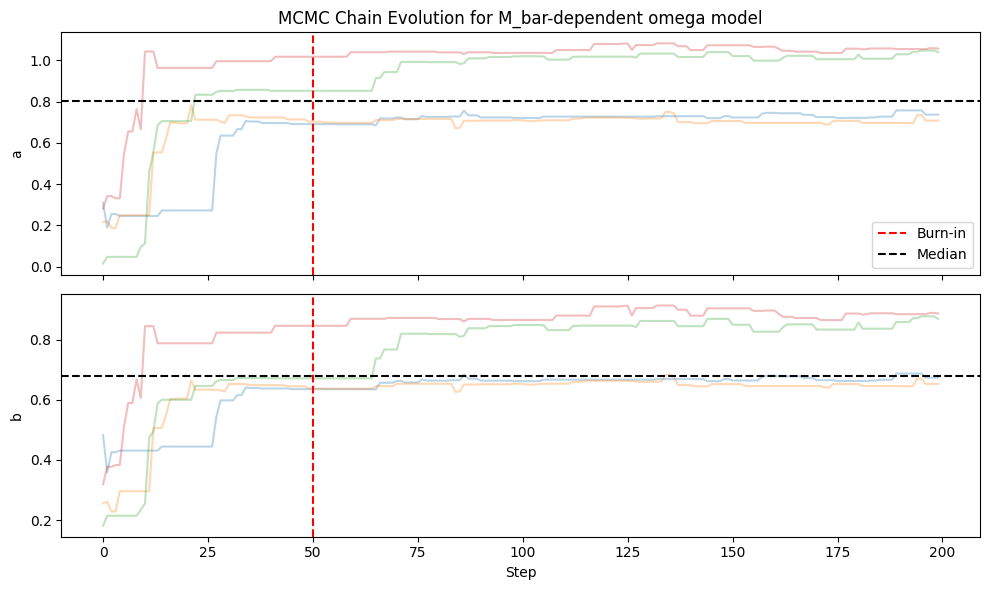

Execution time: 0.1577 seconds


In [55]:
# Plot MCMC diagnostics

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
labels = ['a', 'b']
chain = sampler_Mdep_omega.get_chain()

for i in range(2):
    ax = axes[i]
    ax.plot(chain[:, :, i], alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.axvline(n_steps//4, color='r', linestyle='--', label='Burn-in')
    ax.axhline(np.median(flat_samples_Mdep_omega[:, i]), color='k', linestyle='--', label='Median')

axes[-1].set_xlabel("Step")
axes[0].set_title("MCMC Chain Evolution for M_bar-dependent omega model")
axes[0].legend(loc='lower right')
plt.tight_layout()
plt.show()
fig.savefig('../outputs/graphs_elise_new_rot/mcmc_chain_Mdep_omega.png', dpi=300)

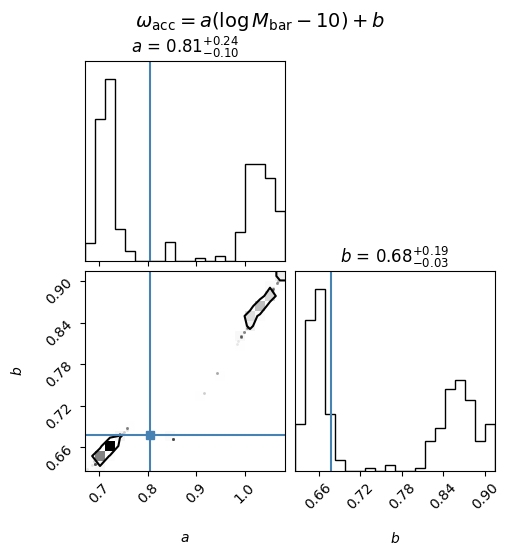

Execution time: 0.1285 seconds


In [50]:
# Corner plot

fig_corner = plot_corner_Mdep_omega(
    flat_samples_Mdep_omega, 
    labels=[r'$a$', r'$b$'],
    title="$\\omega_{\\rm acc} = a(\\log M_{\\rm bar} - 10) + b$"
)
if fig_corner is not None:
    plt.show()
    fig_corner.savefig('../outputs/graphs_elise_new_rot/corner_Mdep_omega.png', dpi=300)

In [33]:
# Plot model with best-fit parameters vs data

log_M_grid = np.linspace(8, 11.5, 50)

r_acc_grid_bestfit = np.zeros((len(log_M_grid), 10))
j_acc_grid_bestfit = np.zeros((len(log_M_grid), 10))
for i, logM in enumerate(log_M_grid):
    r_acc_grid_bestfit[i], j_acc_grid_bestfit[i] = build_r_acc_for_single_M(logM, n_j=10)

r_acc_grid_bestfit_jax = jnp.array(r_acc_grid_bestfit, dtype=jnp.float64)
log_M_grid_jax = jnp.array(log_M_grid, dtype=jnp.float64)

print("Running model with best-fit parameters...")
f_gas_bf, j_bar_bf, j_gas_bf, j_star_bf, Ms_bf, Mg_bf = run_all_masses_Mdep_omega_jax(
    log_M_grid_jax, a_median, b_median, r_acc_grid_bestfit_jax
)

f_gas_bestfit = np.array(f_gas_bf)
j_bar_bestfit = np.array(j_bar_bf)
log_j_bar_bestfit = np.log10(j_bar_bestfit)

print("Done!")
print(f"Best-fit omega at logM=10: {omega_Mdep(10.0, a_median, b_median):.4f} Gyr^-1")
print(f"Best-fit t_acc at logM=10: {tacc_Mdep(10.0, a_median, b_median):.2f} Gyr")

Running model with best-fit parameters...
Done!
Best-fit omega at logM=10: 0.6718 Gyr^-1
Best-fit t_acc at logM=10: 1.49 Gyr
Execution time: 2.6683 seconds


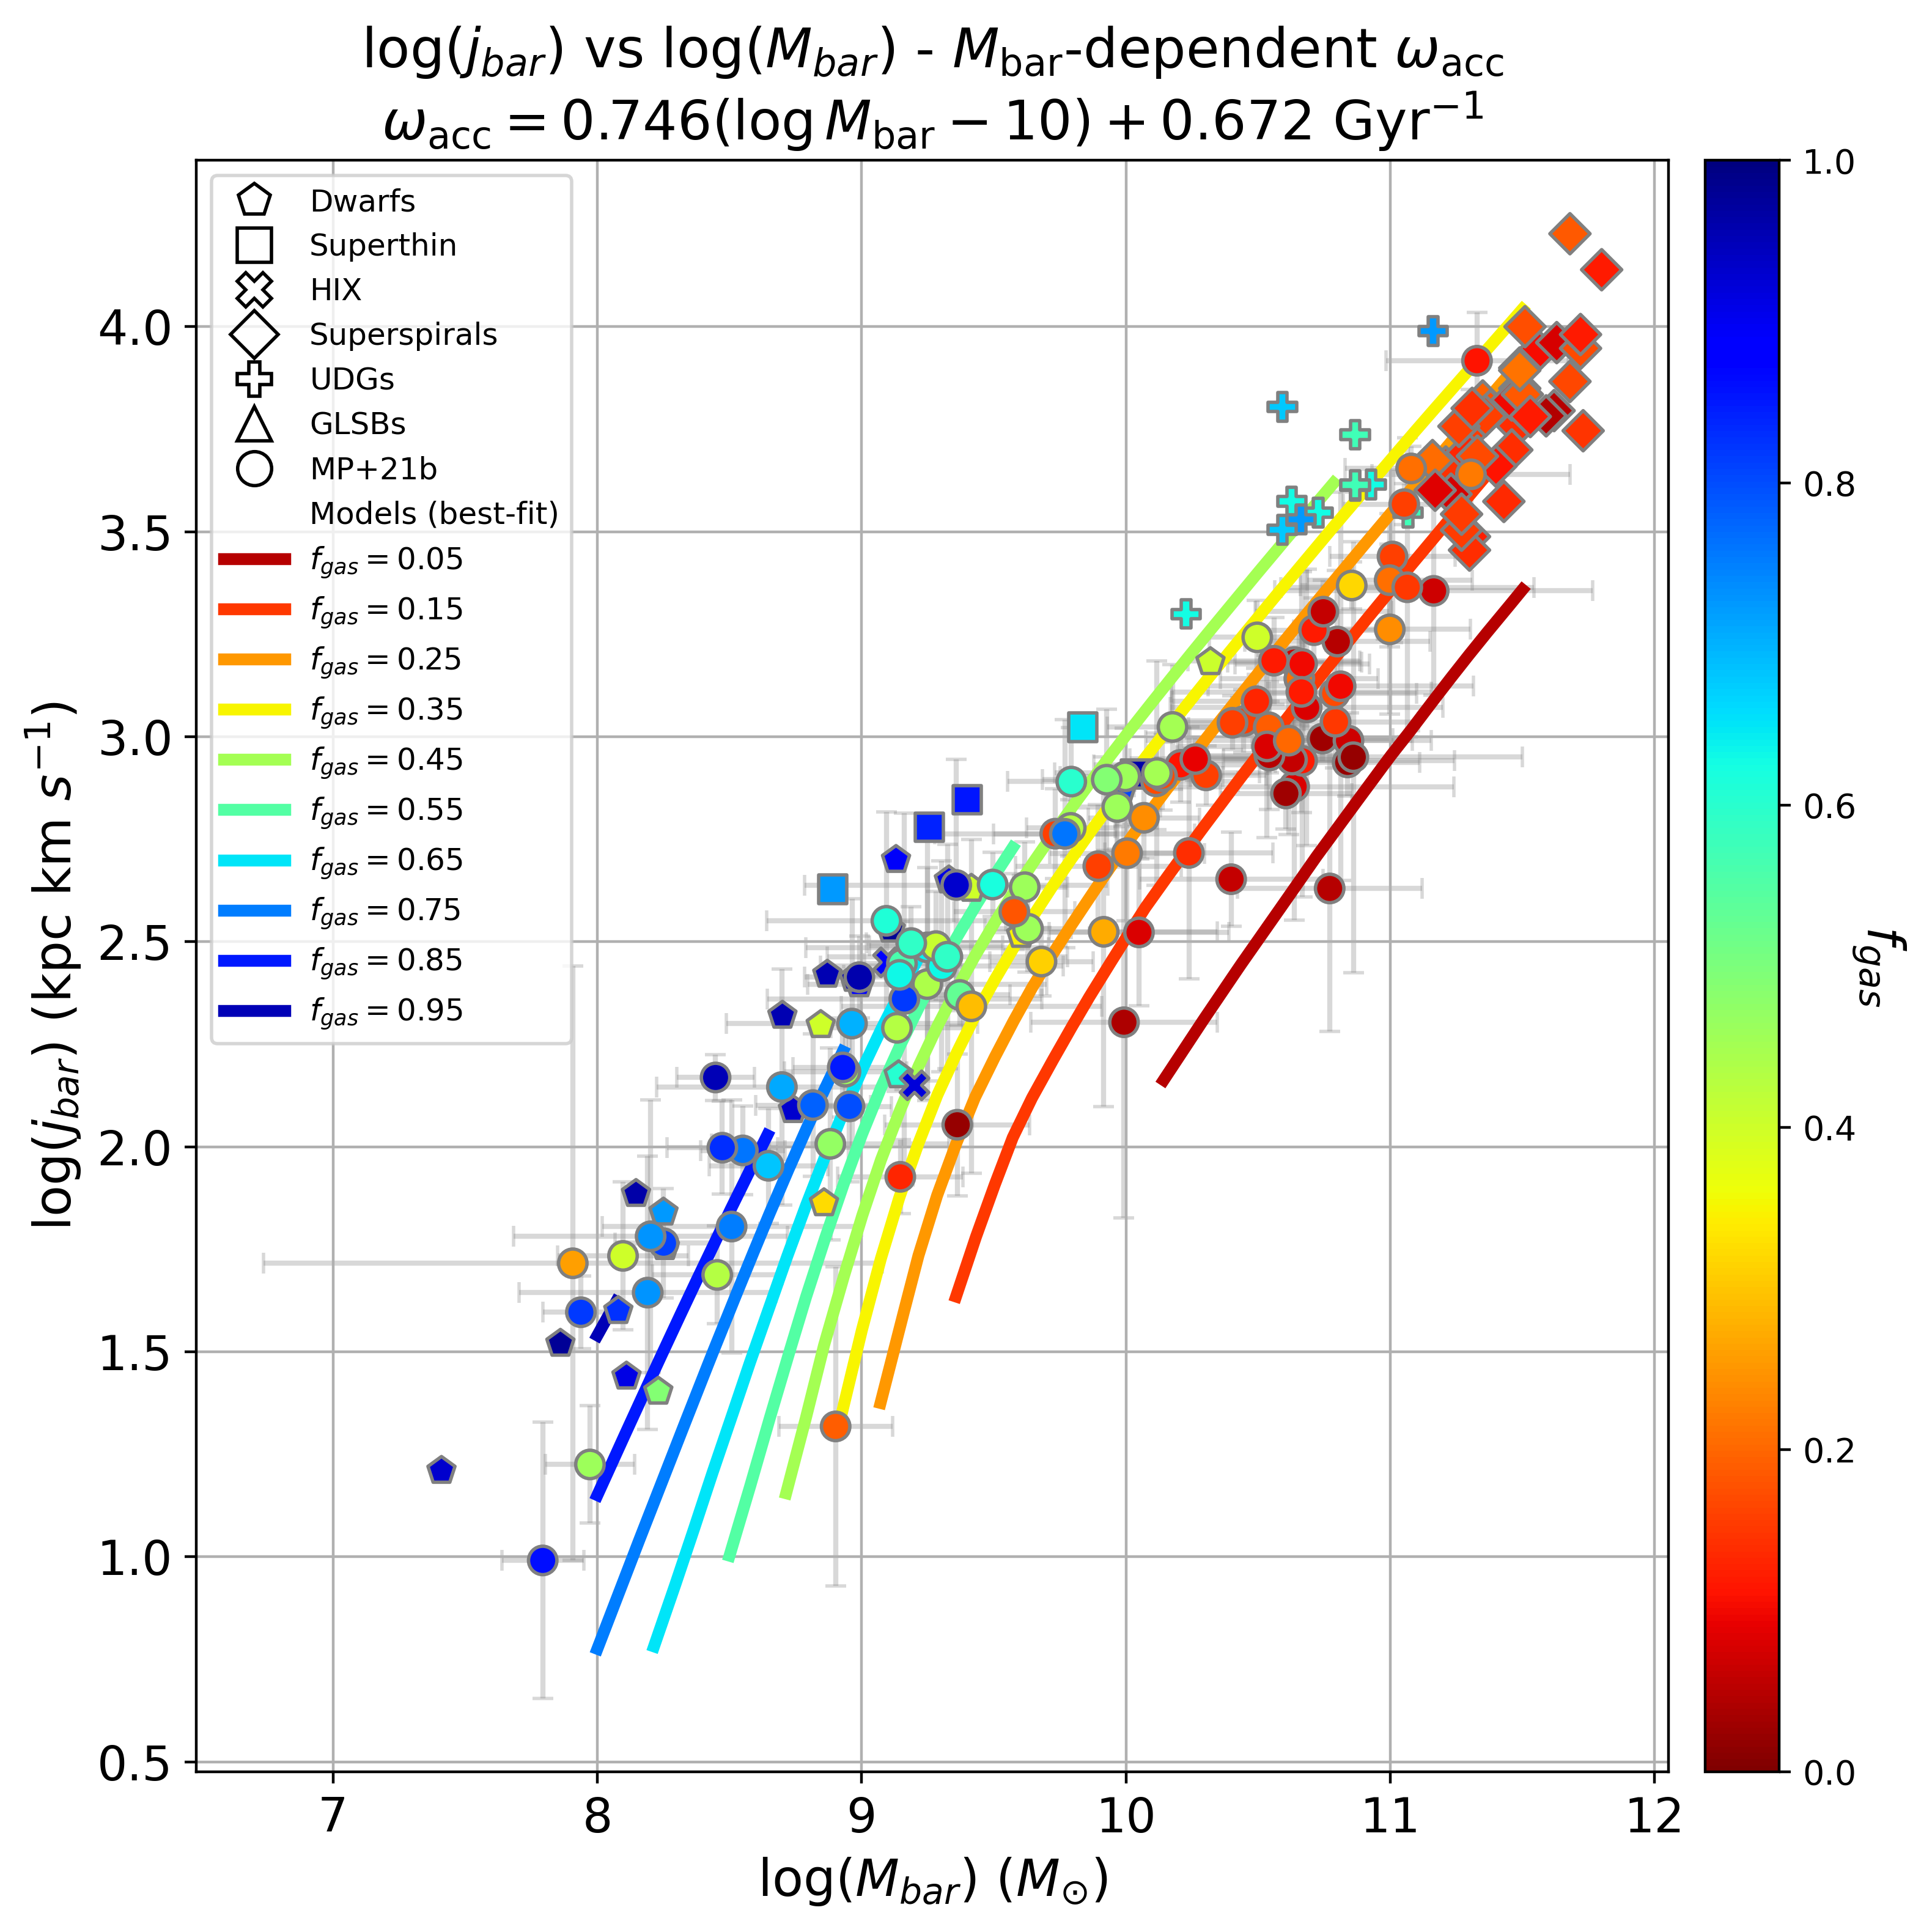

Execution time: 0.8262 seconds


In [41]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8, 8), dpi=400, facecolor='w')
frame = fig.add_subplot(1, 1, 1)

# Colorbar
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

# Model lines at constant f_gas
f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

# Interpolate model to get j_bar at constant f_gas
n_interp = 1000
interp_f_gas_bestfit = np.zeros((len(log_M_grid), n_interp))
interp_j_bar_bestfit = np.zeros((len(log_M_grid), n_interp))

for i in range(len(log_M_grid)):
    f_min, f_max = f_gas_bestfit[i, :].min(), f_gas_bestfit[i, :].max()
    if f_max > f_min:
        interp_f_gas_bestfit[i] = np.linspace(f_min, f_max, n_interp)
        try:
            ipl = spl.interp1d(f_gas_bestfit[i, :], log_j_bar_bestfit[i, :], 
                              kind='linear', fill_value='extrapolate')
            interp_j_bar_bestfit[i] = ipl(interp_f_gas_bestfit[i])
        except:
            interp_j_bar_bestfit[i] = np.nan

log_M_bar_array_backup = log_M_bar_array.copy()
log_M_bar_array = log_M_grid

# Plot model lines
mods = frame.plot([], [], ' ', label="Models (best-fit)")
for i, f_gas_value in enumerate(f_gas_values):
    indexed_M, indexed_j = modelled_j_bar2(interp_f_gas_bestfit, interp_j_bar_bestfit, f_gas_value)
    if len(indexed_M) > 0:
        ax1 = frame.plot(indexed_M, indexed_j, 
                        label=rf"$f_{{gas}} = {f_gas_value:.2f}$", 
                        color=colors[i], lw=3.5, zorder=2)
        ax1s.append(ax1[0])

# Restore original log_M_bar_array
log_M_bar_array = log_M_bar_array_backup

# Filter valid lines
valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if hasattr(x, '__len__') and len(x) > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

# Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", 
                   facecolors=cmap(obs_fgas), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, 
              fmt=' ', ecolor='grey', capsize=3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15, labelpad=15)

# Pavel data
markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
for (idx, df), i in zip(pavel_data.items(), range(3, 8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker,
                           facecolors=cmap(df['fgas'].values.copy()), edgecolors="grey", s=70, zorder=i)

# Legend
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', 
              markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), 
                           ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
legend_elements = (scatter_legend_elements + 
                  [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
                             markeredgecolor='k', markersize=10, label="MP+21b")] + 
                  mods + valid_model_lines)

# Title with best-fit parameters
title_str = (rf"$\log(j_{{bar}})$ vs $\log(M_{{bar}})$ - $M_{{\rm bar}}$-dependent $\omega_{{\rm acc}}$" + "\n" +
            rf"$\omega_{{\rm acc}} = {a_median:.3f}(\log M_{{\rm bar}} - 10) + {b_median:.3f}$ Gyr$^{{-1}}$")
frame.set_title(title_str, fontsize=16)
frame.set_xlabel(r"$\log(M_{bar})$ $(M_{\odot})$", fontsize=15)
frame.set_ylabel(r"$\log(j_{bar})$ (kpc km $s^{-1}$)", fontsize=15)
frame.legend(handles=legend_elements, loc='upper left', fontsize=9)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
# frame.set_xlim([8, 12])
# frame.set_ylim([1, 4.5])

plt.tight_layout()
plt.show()
fig.savefig('../outputs/graphs_elise_new_rot/log_j_bar_vs_log_M_bar_Mdep_omega_bestfit.png', dpi=300)

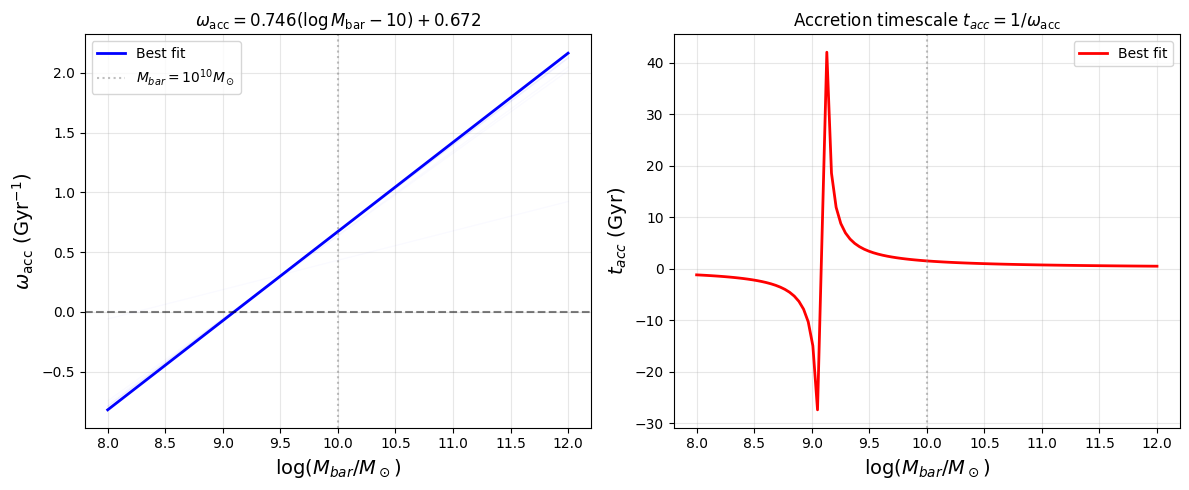

Execution time: 0.2297 seconds


In [40]:
# Plot omega vs M_bar from best-fit

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

logM_plot = np.linspace(8, 12, 100)
omega_plot = omega_Mdep(logM_plot, a_median, b_median)
tacc_plot = tacc_Mdep(logM_plot, a_median, b_median)

# Left panel: omega vs logM
ax1 = axes[0]
ax1.plot(logM_plot, omega_plot, 'b-', lw=2, label='Best fit')
ax1.axhline(0, color='k', linestyle='--', alpha=0.5)
ax1.axvline(10, color='gray', linestyle=':', alpha=0.5, label=r'$M_{bar} = 10^{10} M_\odot$')

# Draw uncertainty band from MCMC samples
for i in range(0, len(flat_samples_Mdep_omega), 100):
    a_s, b_s = flat_samples_Mdep_omega[i]
    omega_s = omega_Mdep(logM_plot, a_s, b_s)
    ax1.plot(logM_plot, omega_s, 'b-', alpha=0.02, lw=1)

ax1.set_xlabel(r'$\log(M_{bar}/M_\odot)$', fontsize=14)
ax1.set_ylabel(r'$\omega_{\rm acc}$ (Gyr$^{-1}$)', fontsize=14)
ax1.set_title(rf'$\omega_{{\rm acc}} = {a_median:.3f}(\log M_{{\rm bar}} - 10) + {b_median:.3f}$', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# Right panel: t_acc vs logM
ax2 = axes[1]
# Only plot where omega is not too close to zero
valid_mask = np.abs(omega_plot) > 0.01
ax2.plot(logM_plot[valid_mask], tacc_plot[valid_mask], 'r-', lw=2, label='Best fit')
ax2.axvline(10, color='gray', linestyle=':', alpha=0.5)

ax2.set_xlabel(r'$\log(M_{bar}/M_\odot)$', fontsize=14)
ax2.set_ylabel(r'$t_{acc}$ (Gyr)', fontsize=14)
ax2.set_title(r'Accretion timescale $t_{acc} = 1/\omega_{\rm acc}$', fontsize=12)
# ax2.set_ylim([-50, 50])
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig('../outputs/graphs_elise_new_rot/omega_tacc_vs_Mbar_bestfit.png', dpi=300)

## Full run

In [14]:
t_acc_array = np.array([3., 25.]) # Gyr
n_M = len(log_M_bar_array)
n_tac = len(t_acc_array)

# Arrays: first index = mass, second index = t_acc
f_gas_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_bar_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_gas_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_star_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
Mstar_grid = np.zeros((n_M, n_tac, 10))
Mgas_grid  = np.zeros((n_M, n_tac, 10))

for j_tac, t_acc in enumerate(t_acc_array):
    print(f"Running models for t_acc = {t_acc:.1f} Gyr")

    # process_mbar takes (M, t_acc)
    process_mbar_cutoff_ksl = partial(process_mbar_old_model, t_acc=t_acc)

    # parallelize over M for this fixed t_acc
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(process_mbar_cutoff_ksl, log_M_bar_array))

    # unpack results into [:, j_tac, :]
    for i_M, (f_gas_temp, j_bar_temp, j_gas_temp, j_star_temp,
              Ms_temp,   Mg_temp) in enumerate(results):

        f_gas_array_10_50_cutoff_ksl[i_M, j_tac, :] = f_gas_temp
        j_bar_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_bar_temp
        j_gas_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_gas_temp
        j_star_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_star_temp
        Mstar_grid[i_M, j_tac, :] = Ms_temp
        Mgas_grid[i_M, j_tac, :] = Mg_temp

np.save('../data/data_elise_new_rot/final_f_gas_cutoff_ksl.npy', f_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_bar_cutoff_ksl.npy', j_bar_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_gas_cutoff_ksl.npy', j_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_star_cutoff_ksl.npy', j_star_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_Mstar_grid_cutoff_ksl.npy', Mstar_grid)
np.save('../data/data_elise_new_rot/final_Mgas_grid_cutoff_ksl.npy', Mgas_grid)

Running models for t_acc = 3.0 Gyr


/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
  f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:143: RuntimeWarning: invalid value encountered in divide
  j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:144: RuntimeWarning: invalid value encountered in divide
  j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:145: RuntimeWarning: invalid value encountered in divide
  j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
  f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:143: RuntimeWarning: invalid value encountered in divide
 

Running models for t_acc = 25.0 Gyr


/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
  f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
  f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:143: RuntimeWarning: invalid value encountered in divide
  j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:144: RuntimeWarning: invalid value encountered in divide
  j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:145: RuntimeWarning: invalid value encountered in divide
  j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
 

Execution time: 115.2275 seconds


In [21]:
t_acc_array = np.array([3.0, 10.0, 25.0, -10.0], dtype=float)
t_acc_array_jax = jnp.array(t_acc_array, dtype=jnp.float64)

Mbar_grid = 10.0**log_M_bar_array
Mbar_grid_jax = jnp.array(Mbar_grid, dtype=jnp.float64)

f_gas_all_jax, j_bar_all_jax, j_gas_all_jax, j_star_all_jax, Ms_all_jax, Mg_all_jax = \
    run_all_masses_bad_jax(
        Mbar_grid_jax,
        t_acc_array_jax,
        r_acc_grid_jax,
        star_formation_law="cutoff_ksl",
    )

f_gas_array_10_50_cutoff_ksl = np.array(f_gas_all_jax)
j_bar_array_10_50_cutoff_ksl = np.array(j_bar_all_jax)
j_gas_array_10_50_cutoff_ksl = np.array(j_gas_all_jax)
j_star_array_10_50_cutoff_ksl = np.array(j_star_all_jax)
Mstar_grid = np.array(Ms_all_jax)
Mgas_grid  = np.array(Mg_all_jax)

np.save('../data/data_elise_new_rot/final_f_gas_cutoff_ksl_bad_jax.npy', f_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_bar_cutoff_ksl_bad_jax.npy', j_bar_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_gas_cutoff_ksl_bad_jax.npy', j_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_star_cutoff_ksl_bad_jax.npy', j_star_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_Mstar_grid_cutoff_ksl_bad_jax.npy', Mstar_grid)
np.save('../data/data_elise_new_rot/final_Mgas_grid_cutoff_ksl_bad_jax.npy', Mgas_grid)

Execution time: 51.9397 seconds


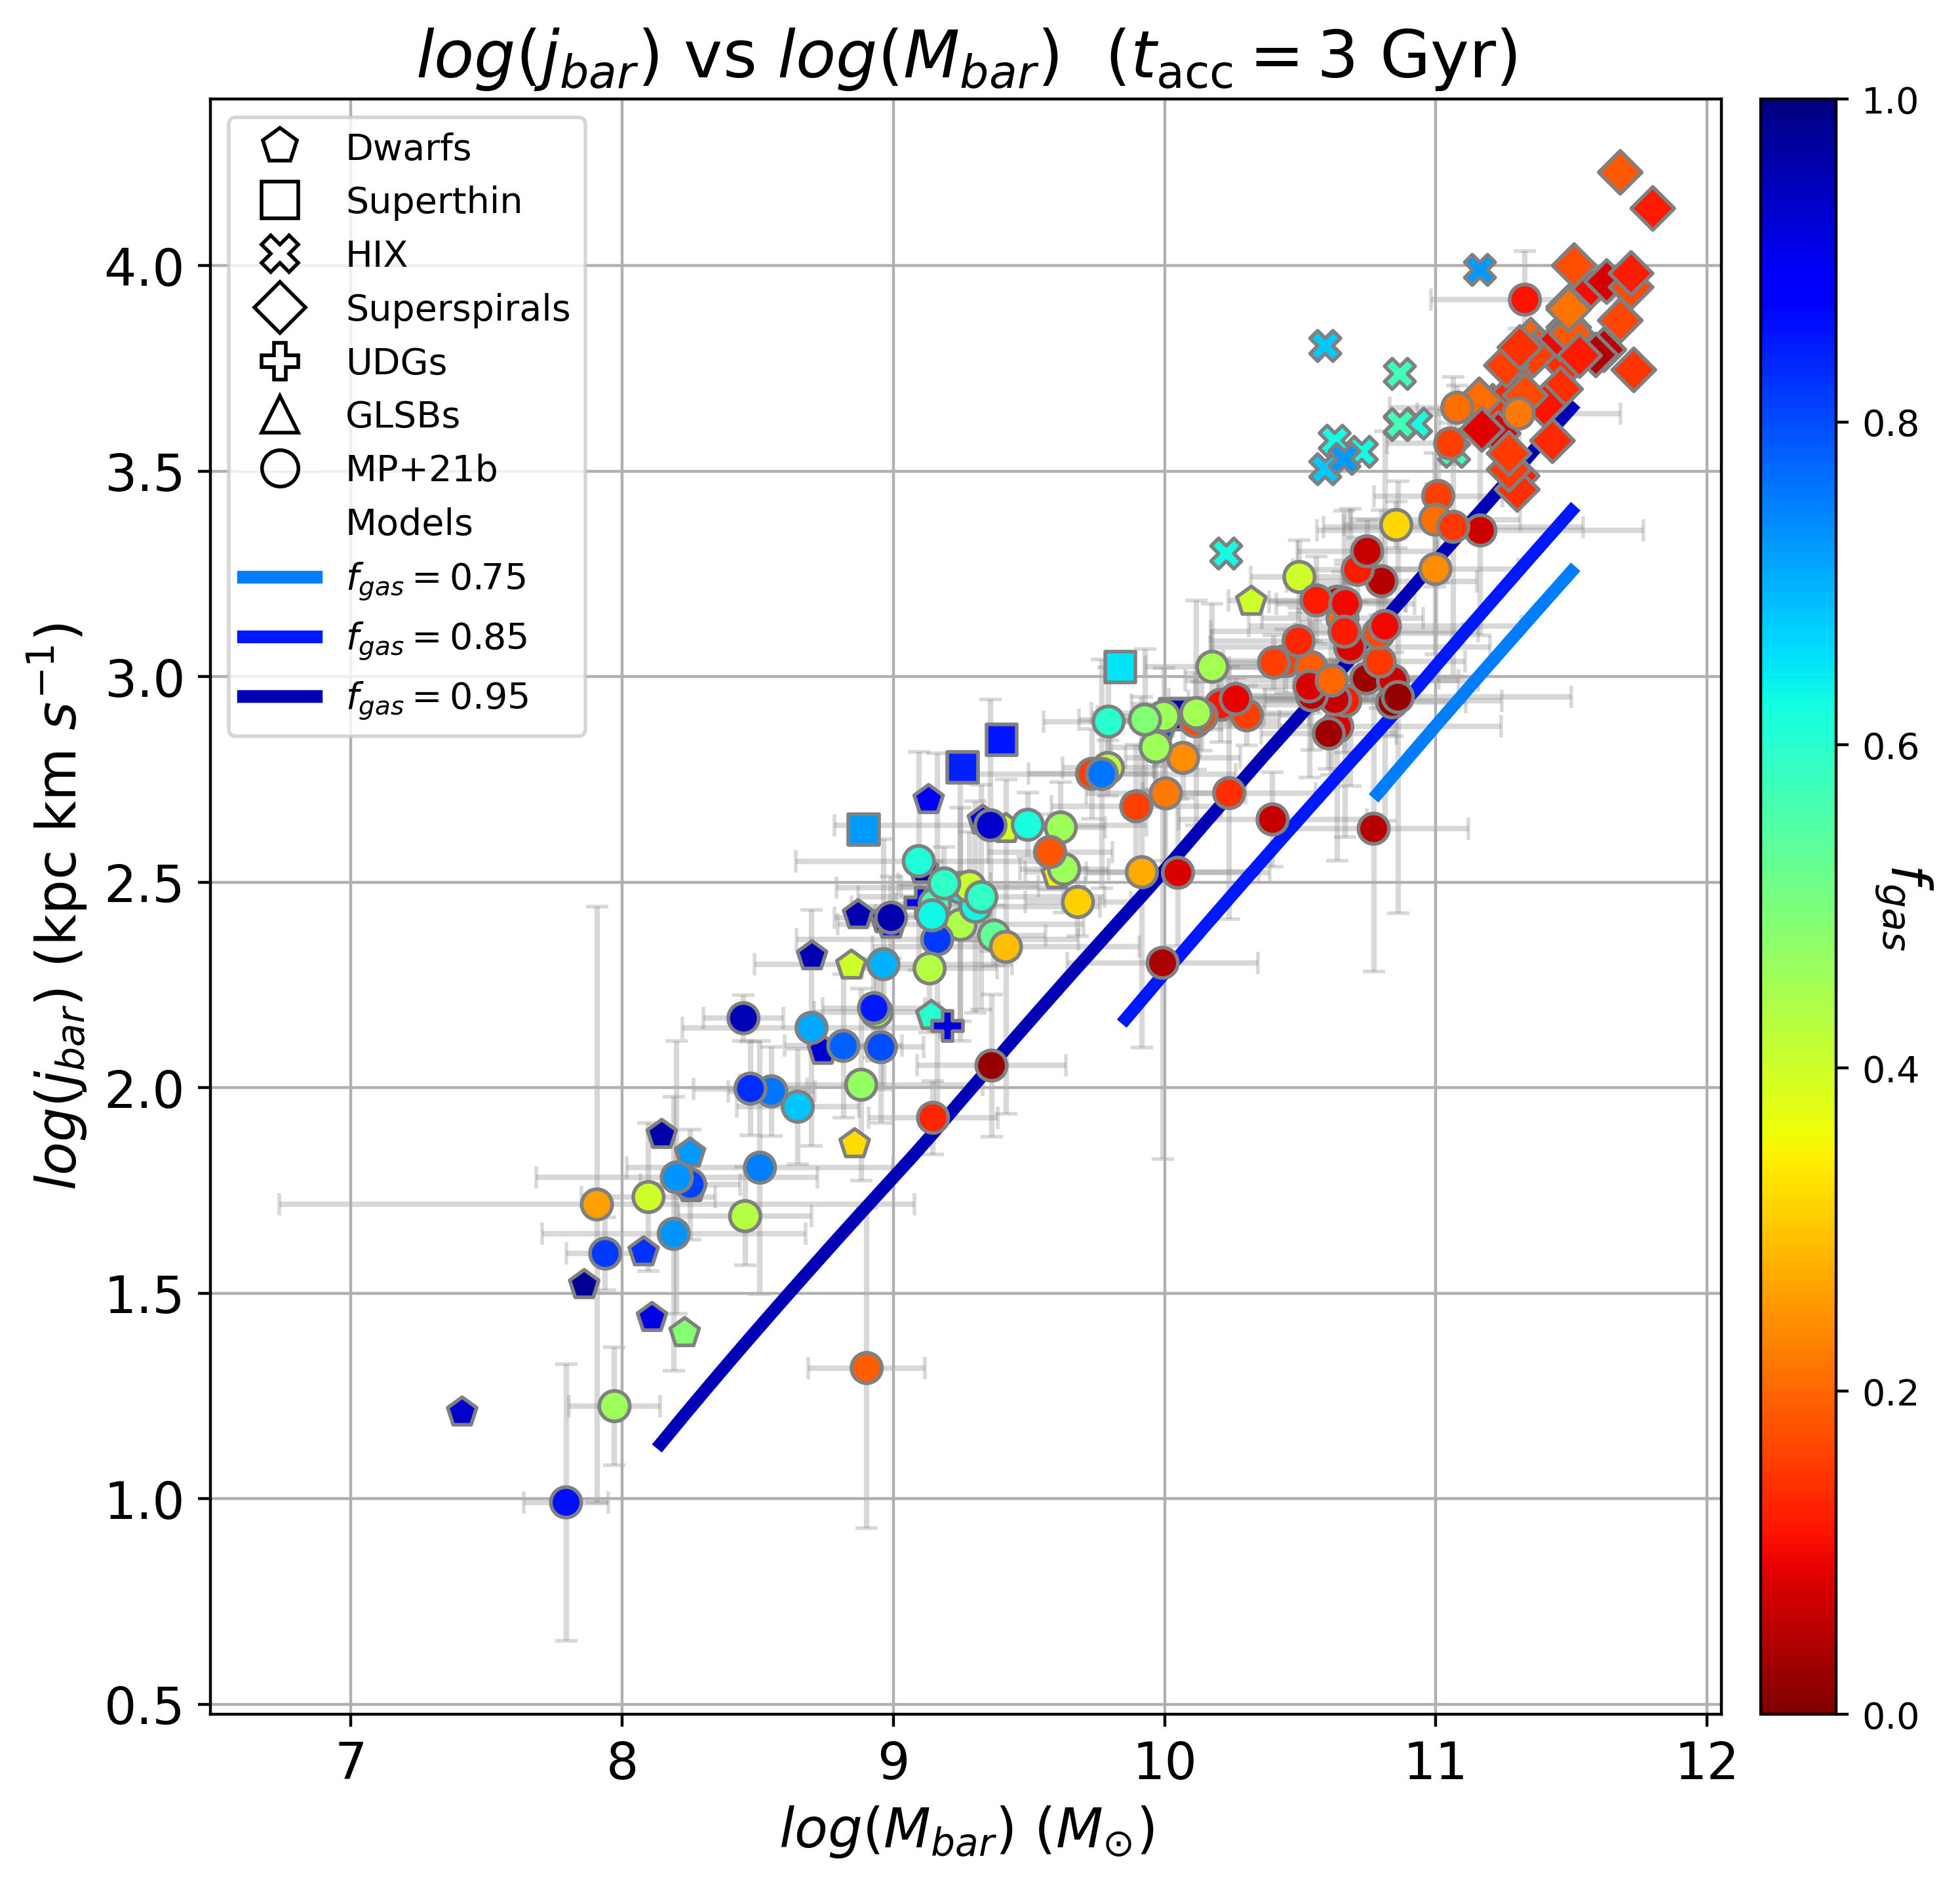

Execution time: 0.8861 seconds


In [15]:
log_j_bar_array_10_50 = np.log10(j_bar_array_10_50_cutoff_ksl)

cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 0, :].min(),f_gas_array_10_50_cutoff_ksl[i, 0, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 0, :], log_j_bar_array_10_50[i, 0, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($t_{\mathrm{acc}} = 3$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')

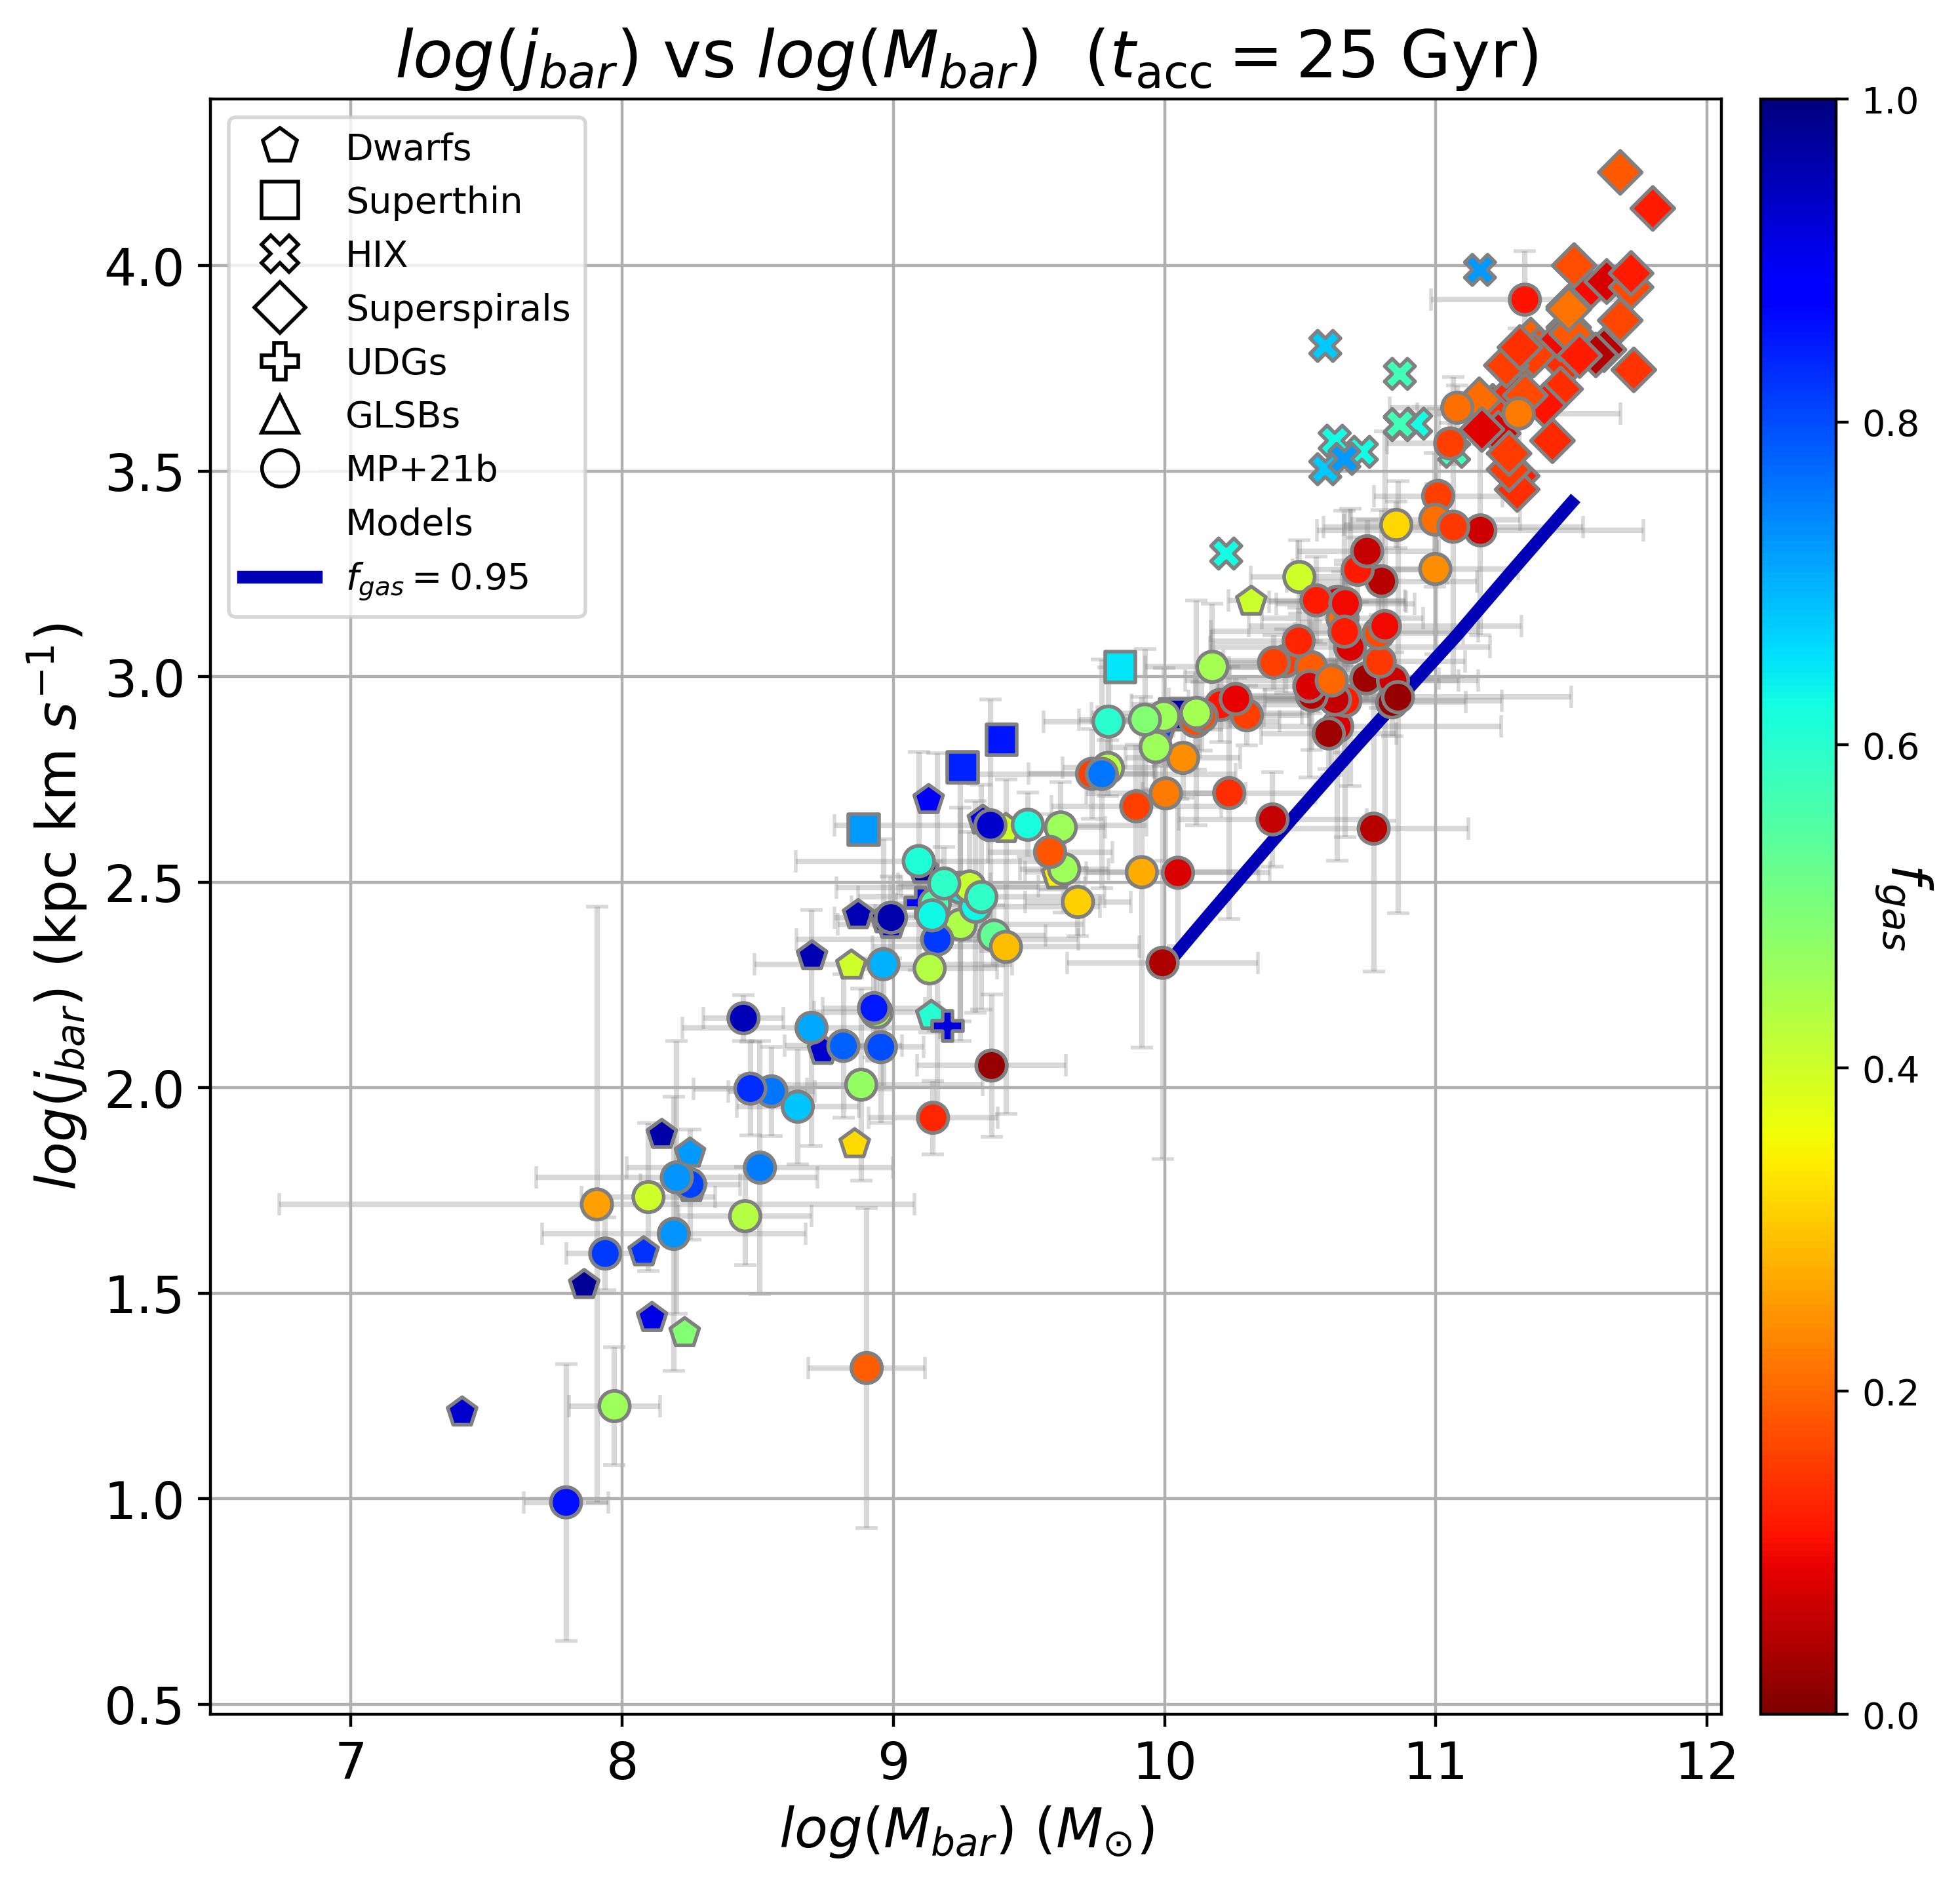

Execution time: 0.8468 seconds


In [16]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 1, :].min(),f_gas_array_10_50_cutoff_ksl[i, 1, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 1, :], log_j_bar_array_10_50[i, 1, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($t_{\mathrm{acc}} = 25$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')

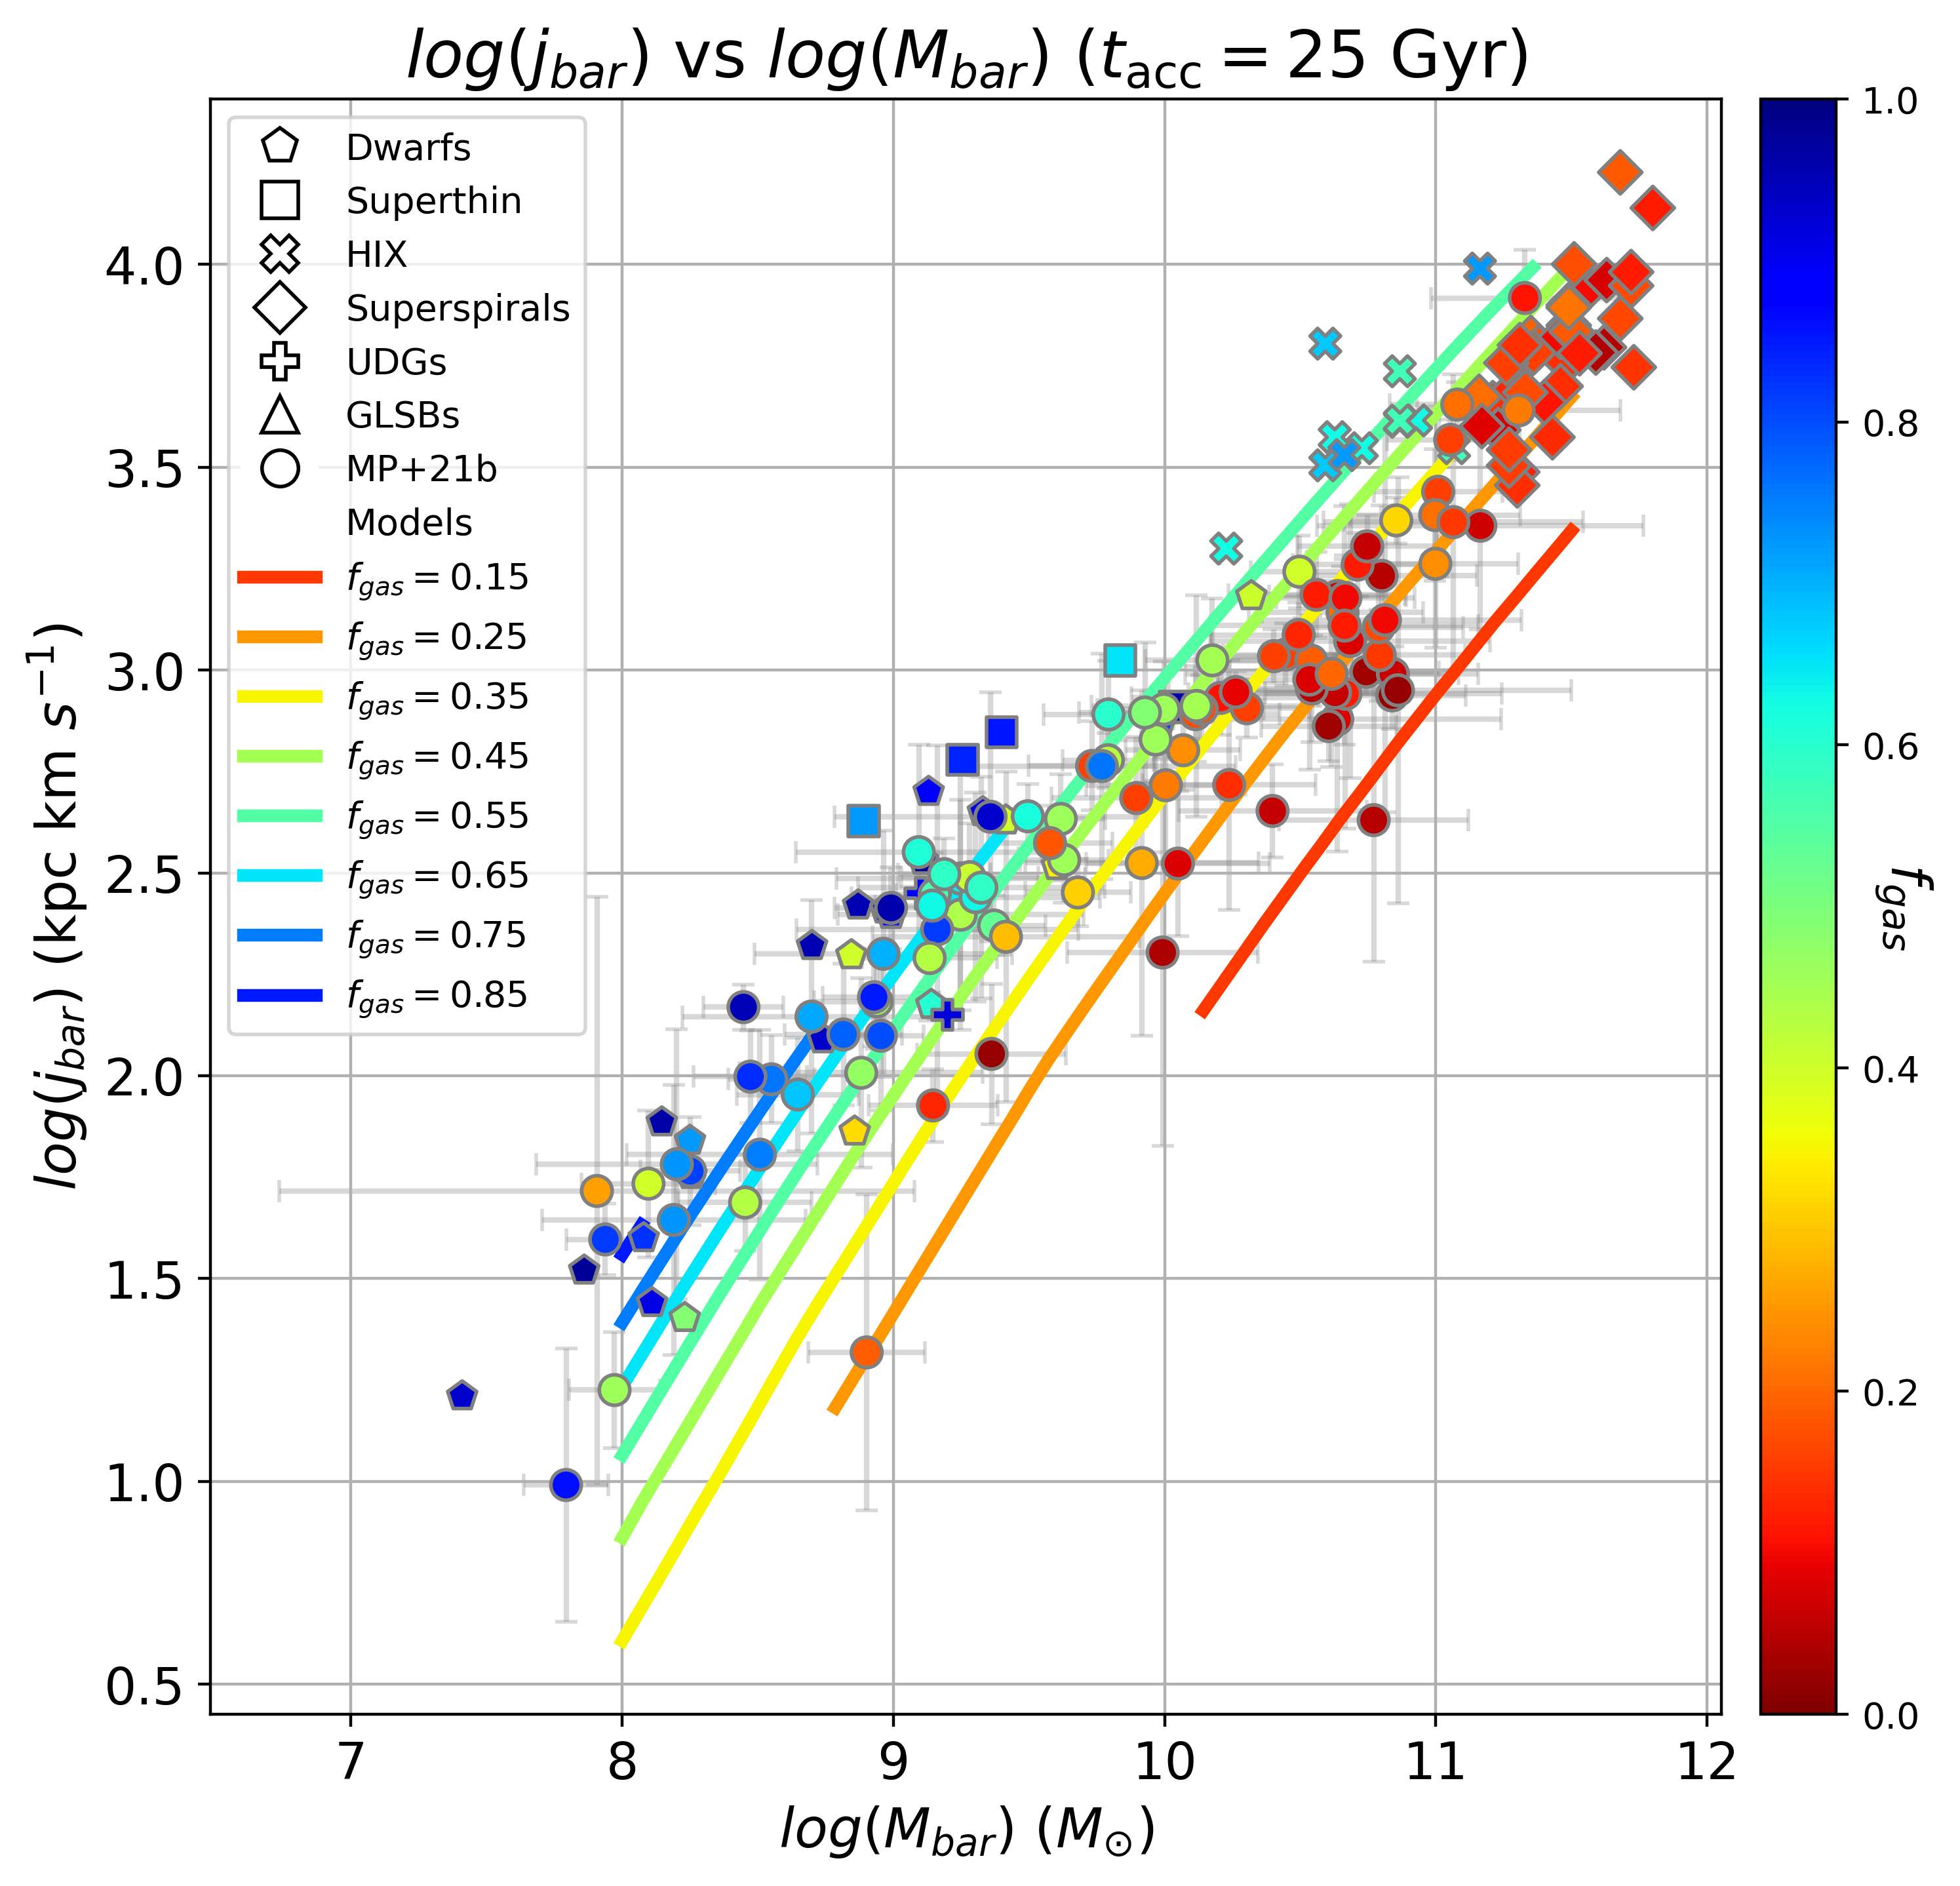

Execution time: 0.9637 seconds


In [29]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 2, :].min(),f_gas_array_10_50_cutoff_ksl[i, 2, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 2, :], log_j_bar_array_10_50[i, 2, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$ ($t_{\mathrm{acc}} = 25$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')

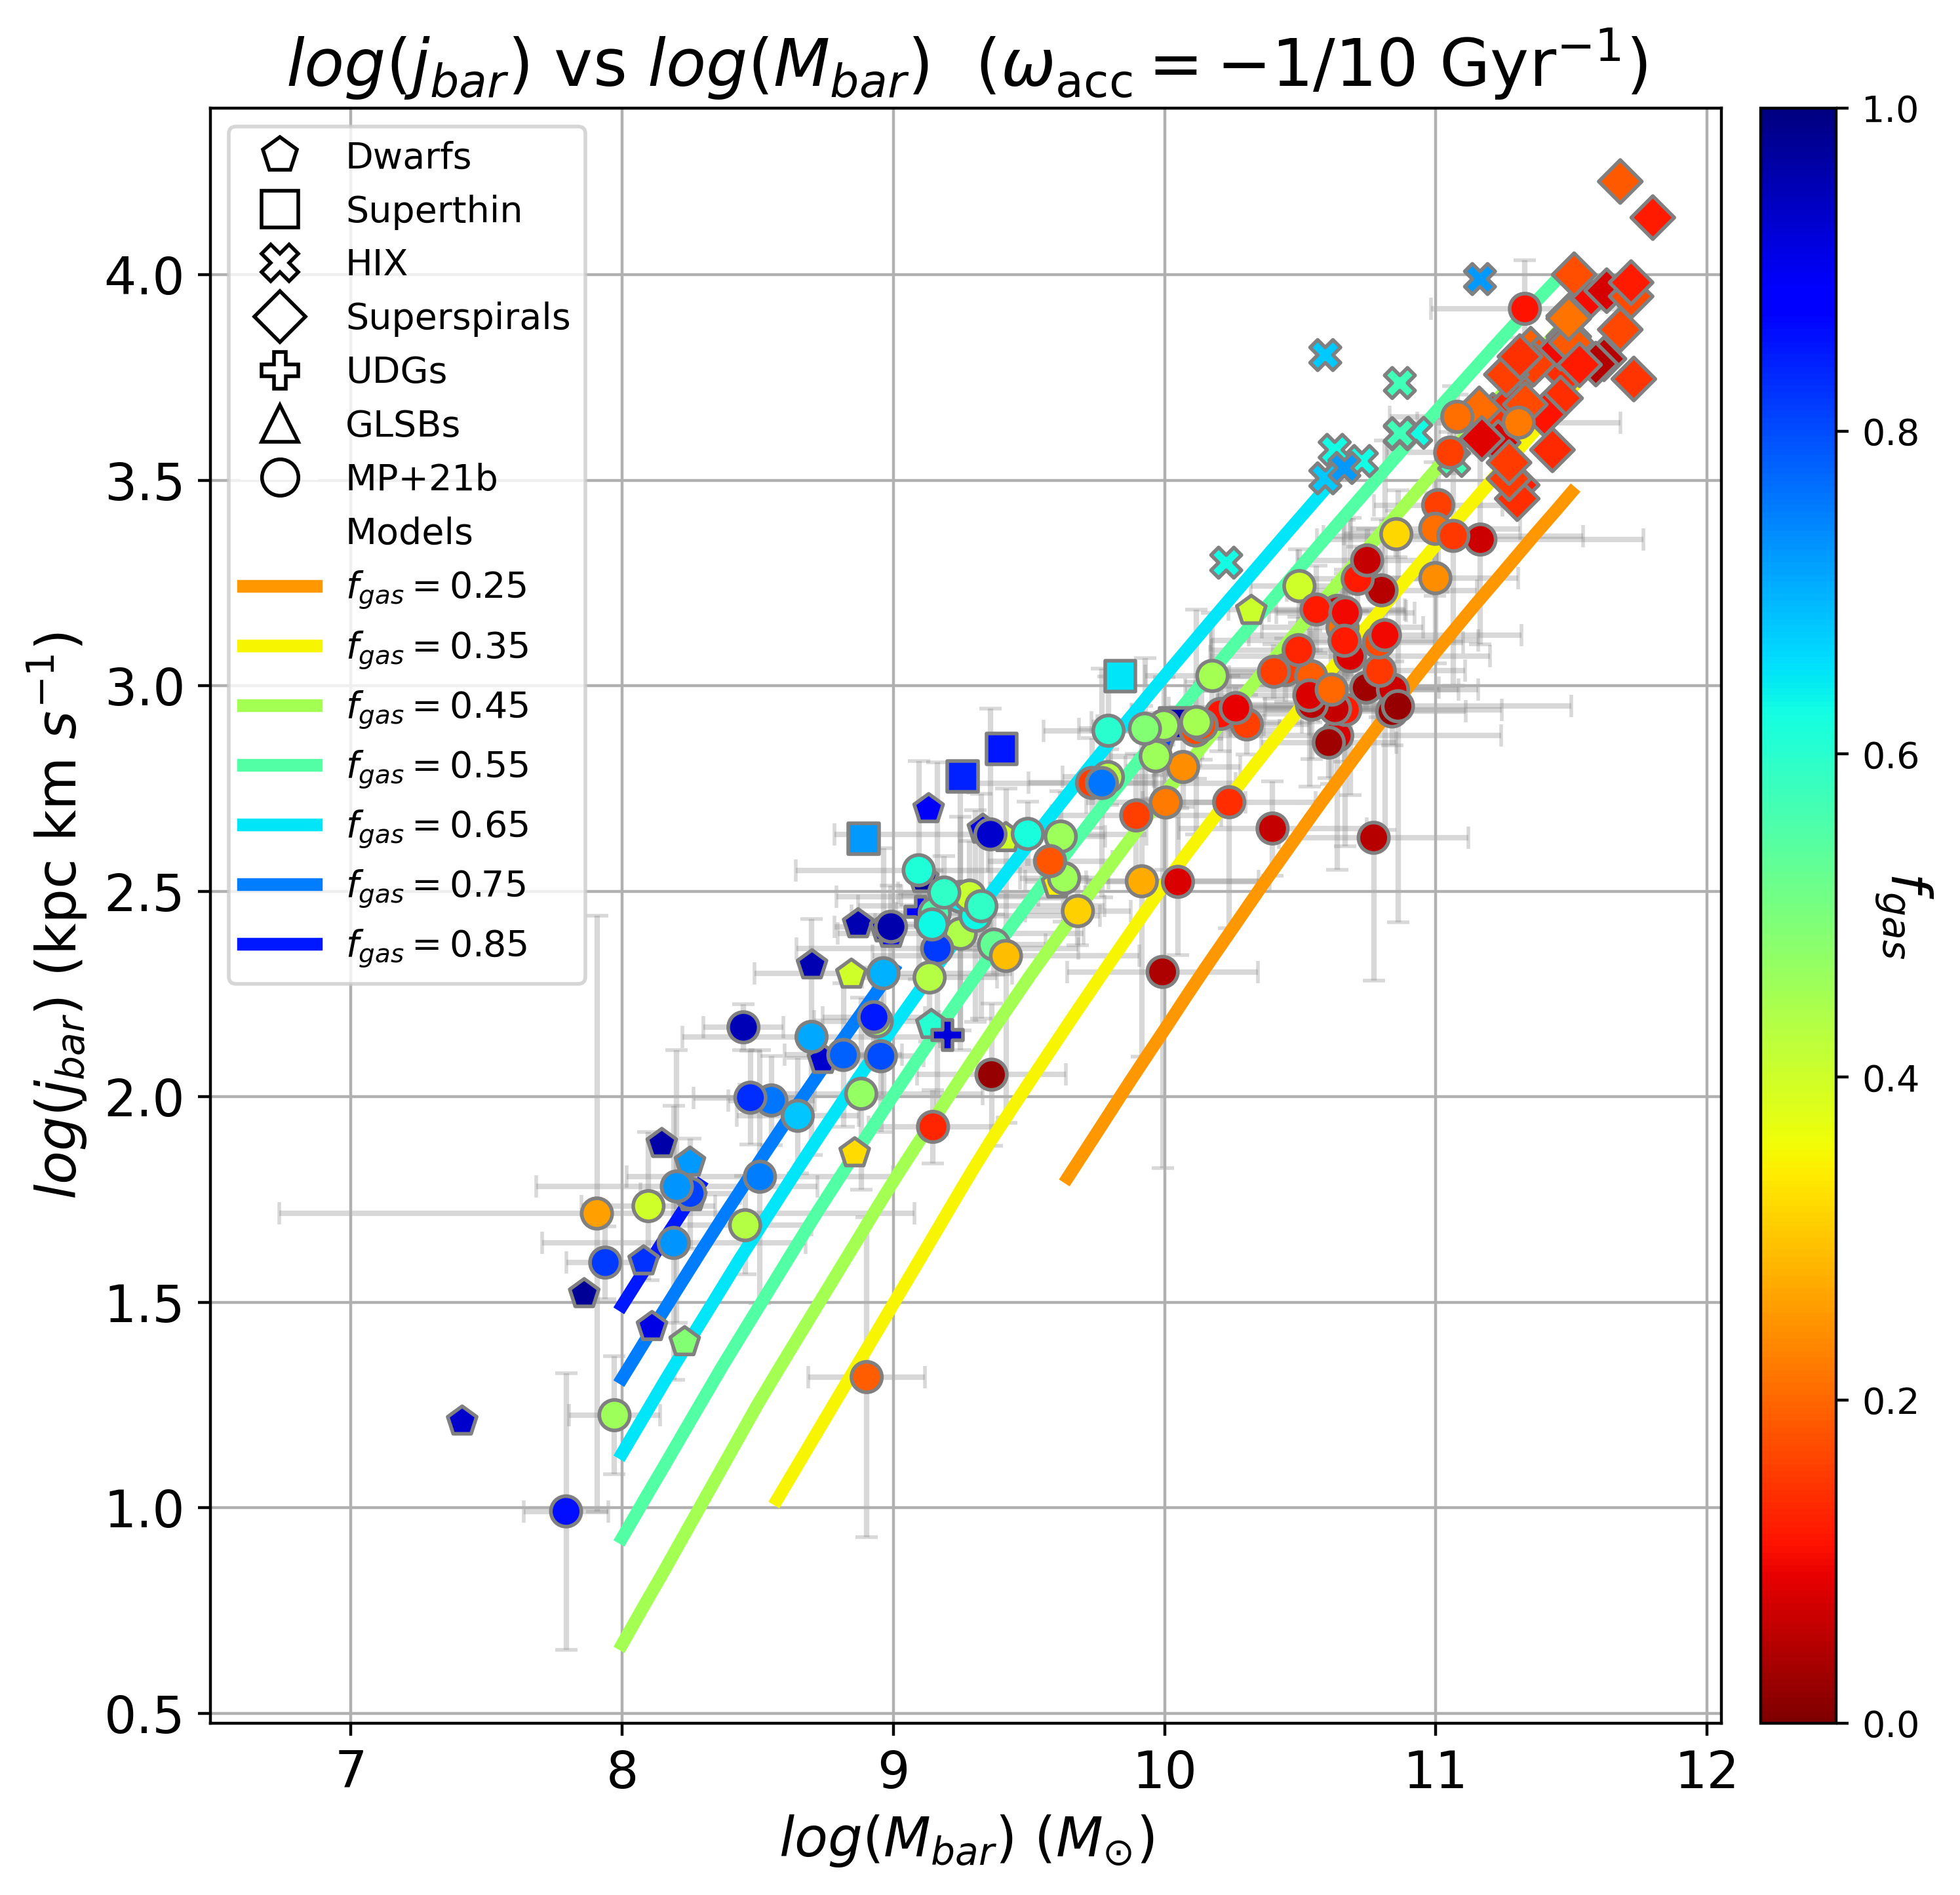

Execution time: 0.9518 seconds


In [30]:
log_j_bar_array_10_50 = np.log10(j_bar_array_10_50_cutoff_ksl)

cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 3, :].min(),f_gas_array_10_50_cutoff_ksl[i, 3, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 3, :], log_j_bar_array_10_50[i, 3, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($\omega_{\mathrm{acc}} = -1/10$ Gyr$^{-1}$)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')